#  Credit Portfolio Risk Monitoring & Prediction

> **Dataset:** Home Credit Default Risk (Kaggle)  
> **Mục tiêu:** Giám sát KPI danh mục tín dụng (DPD, Vintage, Roll Rate), xây dựng mô hình credit scoring, theo dõi độ ổn định mô hình (PSI/CSI)

---

##  Cấu trúc Notebook

| # | Phần | Nội dung chính |
|---|------|----------------|
| 1 | Setup & Data Loading | Import thư viện, nạp 7 bảng dữ liệu |
| 2 | EDA | Phân phối target, missing values, outlier, correlation |
| 3 | Feature Engineering | Tạo ratio, EXT_SOURCE composite, bureau agg |
| 4 | Portfolio Risk KPI | DPD, Delinquency Rate, Vintage, Roll Rate |
| 5 | Hypothesis Testing | Kiểm định thống kê, A/B Test chính sách |
| 6 | Credit Scoring Model | LR → LightGBM → XGBoost → Ensemble |
| 7 | Score Monitoring | PSI, CSI |
| 8 | Economic Value | Định lượng giá trị kinh tế của mô hình |

---


## 1. Setup & Data Loading

In [1]:
# ── Thư viện cần thiết cho toàn bộ pipeline tín dụng ──────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency, ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, precision_recall_curve,
                             f1_score, precision_score, recall_score)
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
SEED = 42
print("✓ Libraries loaded")


✓ Libraries loaded


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
# Option A: Kaggle (uncomment nếu chạy trên Kaggle/Colab)
import kagglehub
path = kagglehub.dataset_download("julianocosta/home-credit")

# # Option B: Local path
# path = "/path/to/home-credit"   # <-- chỉnh lại

app_train    = pd.read_csv(os.path.join(path, "application_train.csv"))
bureau       = pd.read_csv(os.path.join(path, "bureau.csv"))
bureau_bal   = pd.read_csv(os.path.join(path, "bureau_balance.csv"))
prev_app     = pd.read_csv(os.path.join(path, "previous_application.csv"))
installments = pd.read_csv(os.path.join(path, "installments_payments.csv"))
pos_cash     = pd.read_csv(os.path.join(path, "POS_CASH_balance.csv"))
credit_card  = pd.read_csv(os.path.join(path, "credit_card_balance.csv"))

print(f"app_train    : {app_train.shape}")
print(f"bureau       : {bureau.shape}")
print(f"installments : {installments.shape}")
print(f"prev_app     : {prev_app.shape}")


Using Colab cache for faster access to the 'home-credit' dataset.
app_train    : (307511, 122)
bureau       : (1716428, 17)
installments : (13605401, 8)
prev_app     : (1670214, 37)


## 2. EDA — Data Understanding

### 2.2 Feature Groups

In [3]:
# ── Feature group classification ───────────────────────────────────────────
cols_id        = ['SK_ID_CURR']
cols_target    = ['TARGET']
cols_personal  = ['CODE_GENDER','DAYS_BIRTH','CNT_CHILDREN','NAME_FAMILY_STATUS',
                  'NAME_EDUCATION_TYPE','NAME_INCOME_TYPE','DAYS_EMPLOYED',
                  'CNT_FAM_MEMBERS','OCCUPATION_TYPE','DAYS_REGISTRATION',
                  'DAYS_ID_PUBLISH','DAYS_LAST_PHONE_CHANGE']
cols_financial = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
                  'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
cols_contract  = ['NAME_CONTRACT_TYPE','NAME_TYPE_SUITE','FLAG_OWN_CAR',
                  'FLAG_OWN_REALTY','OWN_CAR_AGE','NAME_HOUSING_TYPE']
cols_region    = ['REGION_POPULATION_RELATIVE','REGION_RATING_CLIENT',
                  'REGION_RATING_CLIENT_W_CITY','ORGANIZATION_TYPE']
cols_building  = [c for c in app_train.columns if any(x in c for x in ['_AVG','_MODE','_MEDI'])]
cols_flag_doc  = [c for c in app_train.columns if 'FLAG_DOCUMENT' in c]

print(f"{'Group':<30} {'Cols':>5}")
print("─" * 37)
for name, lst in [("Personal", cols_personal), ("Financial", cols_financial),
                  ("Contract & Asset", cols_contract), ("Region", cols_region),
                  ("Building AVG/MODE/MEDI", cols_building), ("Flag Documents", cols_flag_doc)]:
    print(f"{name:<30} {len(lst):>5}")
print(f"\n→ Building + Flag Documents ({len(cols_building)+len(cols_flag_doc)} cols) "
      "will be dropped — high missing, low discriminative power")


Group                           Cols
─────────────────────────────────────
Personal                          12
Financial                          7
Contract & Asset                   6
Region                             4
Building AVG/MODE/MEDI            47
Flag Documents                    20

→ Building + Flag Documents (67 cols) will be dropped — high missing, low discriminative power


### 2.3 Target Distribution

TARGET = 0 (Good) : 282,686 (91.9%)
TARGET = 1 (Bad)  : 24,825 (8.1%)
Imbalance ratio   : 11:1


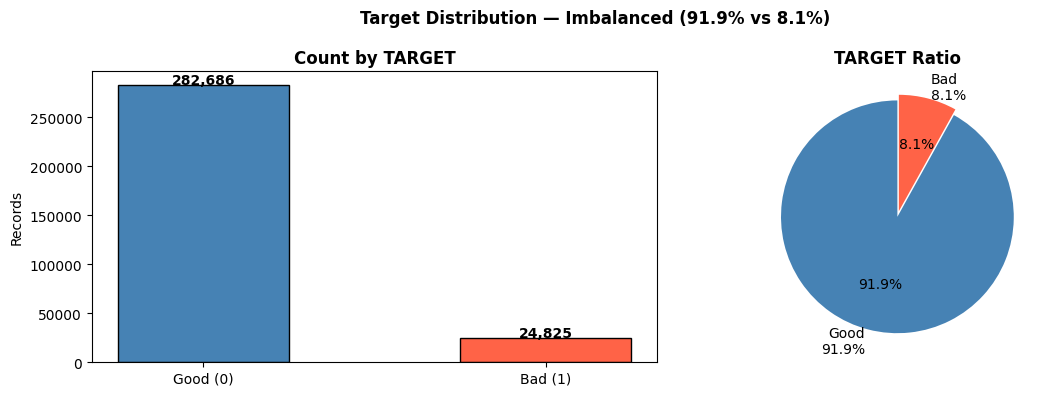

In [4]:
target_count = app_train['TARGET'].value_counts()
target_pct   = app_train['TARGET'].value_counts(normalize=True) * 100

print(f"TARGET = 0 (Good) : {target_count[0]:,} ({target_pct[0]:.1f}%)")
print(f"TARGET = 1 (Bad)  : {target_count[1]:,} ({target_pct[1]:.1f}%)")
print(f"Imbalance ratio   : {target_pct[0]/target_pct[1]:.0f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Good (0)', 'Bad (1)'], target_count.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Count by TARGET', fontweight='bold')
axes[0].set_ylabel('Records')
for i, v in enumerate(target_count.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_count.values,
            labels=[f'Good\n{target_pct[0]:.1f}%', f'Bad\n{target_pct[1]:.1f}%'],
            colors=['steelblue','tomato'], autopct='%1.1f%%',
            startangle=90, explode=(0,0.05))
axes[1].set_title('TARGET Ratio', fontweight='bold')
plt.suptitle('Target Distribution — Imbalanced (91.9% vs 8.1%)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('2.3_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.4 Missing Values

No missing       : 55 cols
Low  (0-10%)     : 7 cols
Medium (10-40%)  : 8 cols
High (>40%)      : 49 cols  → candidates for dropping


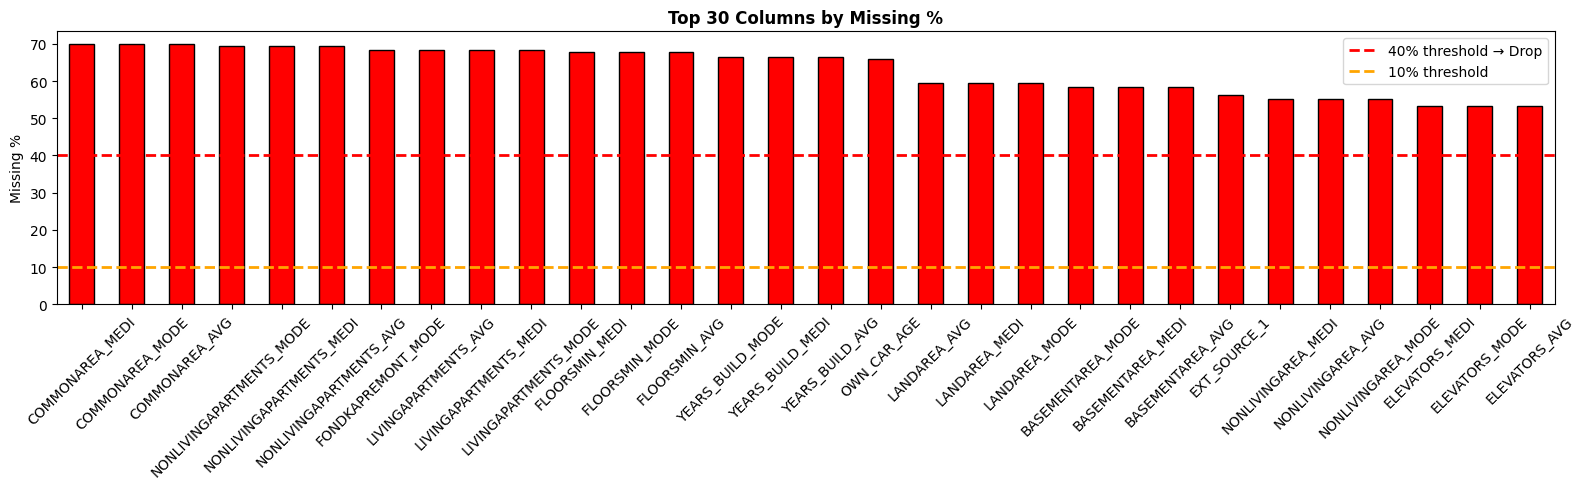

In [5]:
missing     = app_train.isnull().sum()
missing     = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(app_train) * 100).round(2)

high   = missing_pct[missing_pct > 40]
medium = missing_pct[(missing_pct > 10) & (missing_pct <= 40)]
low    = missing_pct[(missing_pct > 0)  & (missing_pct <= 10)]

print(f"No missing       : {app_train.shape[1] - len(missing)} cols")
print(f"Low  (0-10%)     : {len(low)} cols")
print(f"Medium (10-40%)  : {len(medium)} cols")
print(f"High (>40%)      : {len(high)} cols  → candidates for dropping")

fig, ax = plt.subplots(figsize=(16, 5))
missing_pct.head(30).plot(
    kind='bar', ax=ax,
    color=['red' if x > 40 else 'orange' if x > 10 else 'green'
           for x in missing_pct.head(30)],
    edgecolor='black')
ax.axhline(y=40, color='red', linestyle='--', linewidth=2, label='40% threshold → Drop')
ax.axhline(y=10, color='orange', linestyle='--', linewidth=2, label='10% threshold')
ax.set_title('Top 30 Columns by Missing %', fontweight='bold')
ax.set_ylabel('Missing %')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('2.4_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


---
### 2.X — Data Quality: Xử Lý Thiếu, Trùng Lặp & Ngoại Lai


### Ba vấn đề cần xử lý:

| Vấn đề | Phát hiện bằng | Xử lý |
|--------|---------------|-------|
| **Missing Values** | `isnull().sum()` | Drop (>40%), Median impute (10-40%), giữ nguyên (<10%) |
| **Duplicates** | `duplicated()` | Drop hàng trùng, kiểm tra trùng theo SK_ID_CURR |
| **Outliers** | IQR, Z-score, domain knowledge | Capping, transform, hoặc giữ nguyên nếu có nghĩa nghiệp vụ |


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# PHẦN 2.X — DATA QUALITY: XỬ LÝ THIẾU, TRÙNG LẶP, NGOẠI LAI
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 65)
print("BƯỚC 1: KIỂM TRA VÀ XỬ LÝ DỮ LIỆU TRÙNG LẶP (DUPLICATES)")
print("=" * 65)

# ── 1.1 Kiểm tra hàng trùng hoàn toàn ──────────────────────────────────────
# Duplicate rows = cùng toàn bộ giá trị → thường do lỗi ETL/data pipeline
n_dup_rows = app_train.duplicated().sum()
print(f"\nSố hàng trùng hoàn toàn    : {n_dup_rows:,}")
print(f"Tỷ lệ                       : {n_dup_rows/len(app_train)*100:.3f}%")

# ── 1.2 Kiểm tra SK_ID_CURR trùng lặp ──────────────────────────────────────
# SK_ID_CURR là primary key của khách hàng — phải là duy nhất
n_dup_id = app_train['SK_ID_CURR'].duplicated().sum()
print(f"\nSố SK_ID_CURR trùng         : {n_dup_id:,}")
if n_dup_id == 0:
    print("  ✓ Không có ID khách hàng trùng lặp — dữ liệu sạch về mặt key")
else:
    print(f"  ⚠ Phát hiện {n_dup_id} ID trùng — cần điều tra nguyên nhân")
    # Xem các ID bị trùng
    dup_ids = app_train[app_train['SK_ID_CURR'].duplicated(keep=False)]
    print(dup_ids[['SK_ID_CURR','TARGET','AMT_CREDIT']].head(10))

# ── 1.3 Loại bỏ hàng trùng nếu có ──────────────────────────────────────────
# Chỉ drop khi trùng hoàn toàn — không drop khi chỉ trùng ID mà khác thông tin
if n_dup_rows > 0:
    app_train_clean = app_train.drop_duplicates()
    print(f"\n→ Sau khi xóa duplicates: {app_train_clean.shape[0]:,} hàng (giảm {n_dup_rows:,})")
else:
    app_train_clean = app_train.copy()
    print("\n→ Không cần xóa duplicate — giữ nguyên dữ liệu")

print(f"\nShape sau bước 1: {app_train_clean.shape}")


BƯỚC 1: KIỂM TRA VÀ XỬ LÝ DỮ LIỆU TRÙNG LẶP (DUPLICATES)

Số hàng trùng hoàn toàn    : 0
Tỷ lệ                       : 0.000%

Số SK_ID_CURR trùng         : 0
  ✓ Không có ID khách hàng trùng lặp — dữ liệu sạch về mặt key

→ Không cần xóa duplicate — giữ nguyên dữ liệu

Shape sau bước 1: (307511, 122)


BƯỚC 2: XỬ LÝ MISSING VALUES

Tổng cột             : 122
  Không có null      : 55 cột ✓
  Missing 0-10%      : 10 cột  → IMPUTE_OR_KEEP
  Missing 10-40%     : 8 cột  → IMPUTE_MEDIAN
  Missing >40%       : 49 cột  → DROP


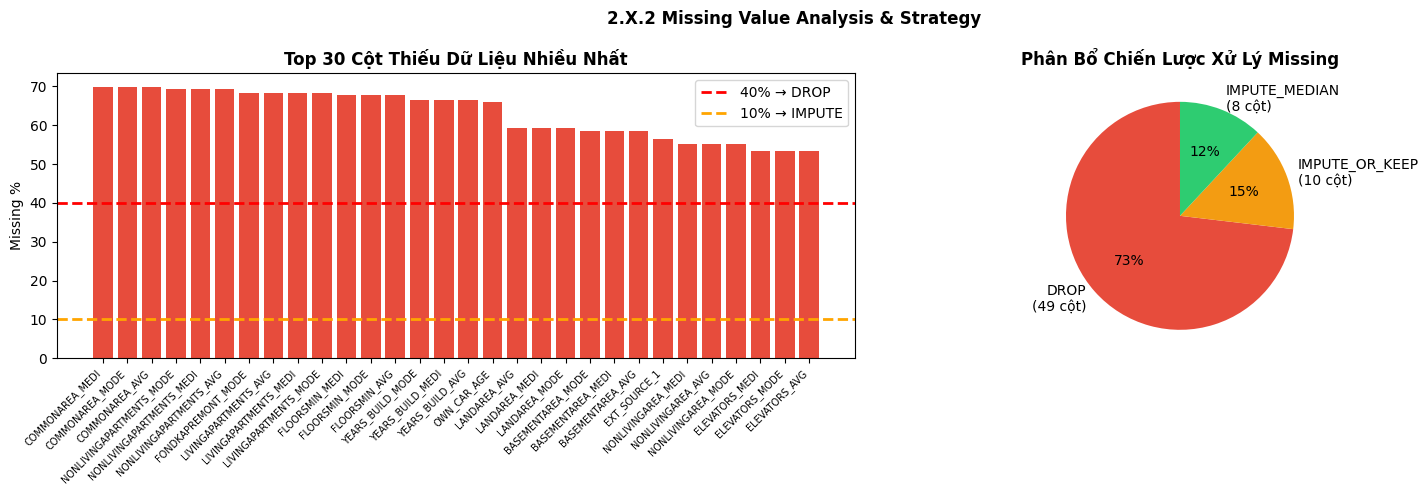


Các cột sẽ DROP (missing > 40%):
                              pct_missing
COMMONAREA_MEDI                   69.8700
COMMONAREA_MODE                   69.8700
COMMONAREA_AVG                    69.8700
NONLIVINGAPARTMENTS_MODE          69.4300
NONLIVINGAPARTMENTS_MEDI          69.4300
NONLIVINGAPARTMENTS_AVG           69.4300
FONDKAPREMONT_MODE                68.3900
LIVINGAPARTMENTS_AVG              68.3500
LIVINGAPARTMENTS_MEDI             68.3500
LIVINGAPARTMENTS_MODE             68.3500
FLOORSMIN_MEDI                    67.8500
FLOORSMIN_MODE                    67.8500
FLOORSMIN_AVG                     67.8500
YEARS_BUILD_MODE                  66.5000
YEARS_BUILD_MEDI                  66.5000
YEARS_BUILD_AVG                   66.5000
OWN_CAR_AGE                       65.9900
LANDAREA_AVG                      59.3800
LANDAREA_MEDI                     59.3800
LANDAREA_MODE                     59.3800
BASEMENTAREA_MODE                 58.5200
BASEMENTAREA_MEDI                 58.5200


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# BƯỚC 2: PHÂN TÍCH VÀ XỬ LÝ MISSING VALUES CHI TIẾT
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("BƯỚC 2: XỬ LÝ MISSING VALUES")
print("=" * 65)

# ── 2.1 Tính tỷ lệ missing cho từng cột ────────────────────────────────────
missing_count = app_train_clean.isnull().sum()
missing_pct   = (missing_count / len(app_train_clean) * 100).round(2)

# Phân loại theo ngưỡng nghiệp vụ tín dụng
missing_summary = pd.DataFrame({
    'n_missing' : missing_count,
    'pct_missing': missing_pct
}).query('n_missing > 0').sort_values('pct_missing', ascending=False)

# Gắn nhãn chiến lược xử lý
def missing_strategy(pct):
    if pct > 40:   return 'DROP'          # Quá nhiều null — không đủ độ tin cậy
    elif pct > 10: return 'IMPUTE_MEDIAN' # Còn thể cứu được — điền median
    else:          return 'IMPUTE_OR_KEEP' # Ít null — có thể giữ hoặc điền

missing_summary['strategy'] = missing_summary['pct_missing'].apply(missing_strategy)

# Thống kê tổng quan
n_drop   = (missing_summary['strategy'] == 'DROP').sum()
n_impute = (missing_summary['strategy'] == 'IMPUTE_MEDIAN').sum()
n_keep   = (missing_summary['strategy'] == 'IMPUTE_OR_KEEP').sum()
n_clean  = app_train_clean.shape[1] - len(missing_summary)

print(f"\nTổng cột             : {app_train_clean.shape[1]}")
print(f"  Không có null      : {n_clean} cột ✓")
print(f"  Missing 0-10%      : {n_keep} cột  → IMPUTE_OR_KEEP")
print(f"  Missing 10-40%     : {n_impute} cột  → IMPUTE_MEDIAN")
print(f"  Missing >40%       : {n_drop} cột  → DROP")

# ── 2.2 Visualize phân bố missing ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot top 30 cột missing nhiều nhất
top30 = missing_summary.head(30)
bar_colors = ['#e74c3c' if s=='DROP' else '#f39c12' if s=='IMPUTE_MEDIAN' else '#2ecc71'
              for s in top30['strategy']]
axes[0].bar(range(len(top30)), top30['pct_missing'], color=bar_colors, edgecolor='none')
axes[0].set_xticks(range(len(top30)))
axes[0].set_xticklabels(top30.index, rotation=45, ha='right', fontsize=7)
axes[0].axhline(y=40, color='red',    linestyle='--', linewidth=2, label='40% → DROP')
axes[0].axhline(y=10, color='orange', linestyle='--', linewidth=2, label='10% → IMPUTE')
axes[0].set_title('Top 30 Cột Thiếu Dữ Liệu Nhiều Nhất', fontweight='bold')
axes[0].set_ylabel('Missing %')
axes[0].legend()

# Pie chart chiến lược
strategy_counts = missing_summary['strategy'].value_counts()
axes[1].pie(strategy_counts.values,
            labels=[f'{k}\n({v} cột)' for k, v in strategy_counts.items()],
            colors=['#e74c3c','#f39c12','#2ecc71'],
            autopct='%1.0f%%', startangle=90)
axes[1].set_title('Phân Bổ Chiến Lược Xử Lý Missing', fontweight='bold')

plt.suptitle('2.X.2 Missing Value Analysis & Strategy', fontweight='bold')
plt.tight_layout()
plt.savefig('2X_missing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# In bảng chi tiết cột sẽ DROP
print("\nCác cột sẽ DROP (missing > 40%):")
print(missing_summary[missing_summary['strategy']=='DROP'][['pct_missing']].to_string())


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# BƯỚC 2 (TIẾP): THỰC HIỆN XỬ LÝ MISSING
# ══════════════════════════════════════════════════════════════════════════════

# ── 2.3 Xác định cột sẽ DROP ────────────────────────────────────────────────
cols_to_drop_missing = missing_summary[missing_summary['strategy'] == 'DROP'].index.tolist()

# ── 2.4 Cột cần impute ──────────────────────────────────────────────────────
cols_to_impute = missing_summary[
    missing_summary['strategy'].isin(['IMPUTE_MEDIAN', 'IMPUTE_OR_KEEP'])
].index.tolist()

app_processed = app_train_clean.copy()

# Drop thật các cột missing quá cao.
# NOTE: bản cũ chỉ tạo cols_to_drop_missing nhưng chưa drop, nên null vẫn còn trong app_processed.
app_processed = app_processed.drop(columns=cols_to_drop_missing, errors='ignore')

# Lọc lại danh sách impute sau khi drop
cols_to_impute = [c for c in cols_to_impute if c in app_processed.columns]

num_impute = app_processed[cols_to_impute].select_dtypes(include=[np.number]).columns.tolist()
cat_impute = app_processed[cols_to_impute].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Cột sẽ DROP          : {len(cols_to_drop_missing)}")
print(f"Cột impute (numeric) : {len(num_impute)}")
print(f"Cột impute (categor) : {len(cat_impute)}")

# ── 2.5 Thực hiện imputation ────────────────────────────────────────────────
for col in num_impute:
    median_val = app_processed[col].median()
    app_processed[col] = app_processed[col].fillna(median_val)

for col in cat_impute:
    mode_series = app_processed[col].mode(dropna=True)
    mode_val = mode_series.iloc[0] if len(mode_series) > 0 else 'Unknown'
    app_processed[col] = app_processed[col].fillna(mode_val)

# ── 2.6 DAYS_EMPLOYED special case ──────────────────────────────────────────
if 'DAYS_EMPLOYED' in app_processed.columns:
    app_processed['DAYS_EMPLOYED_ANOMALY'] = (app_processed['DAYS_EMPLOYED'] == 365243).astype(int)
    n_days_emp_anom = int(app_processed['DAYS_EMPLOYED_ANOMALY'].sum())
    app_processed['DAYS_EMPLOYED'] = app_processed['DAYS_EMPLOYED'].replace(365243, np.nan)
    app_processed['DAYS_EMPLOYED'] = app_processed['DAYS_EMPLOYED'].fillna(
        app_processed['DAYS_EMPLOYED'].median()
    )
    print(f"\nDAYS_EMPLOYED: {n_days_emp_anom:,} anomaly rows → flagged & imputed")

# ── 2.7 Kiểm tra lại sau xử lý ──────────────────────────────────────────────
remaining_null_imputed_cols = app_processed[num_impute + cat_impute].isnull().sum().sum()
remaining_null_total = app_processed.isnull().sum().sum()

print(f"\nNull còn lại trong cột đã impute : {remaining_null_imputed_cols}")
print(f"Null còn lại toàn bộ dữ liệu     : {remaining_null_total}")
print(f"Shape sau xử lý missing          : {app_processed.shape}")


Cột sẽ DROP          : 49
Cột impute (numeric) : 16
Cột impute (categor) : 2

DAYS_EMPLOYED: 55,374 anomaly rows → flagged & imputed

Null còn lại trong cột đã impute : 0
Null còn lại toàn bộ dữ liệu     : 0
Shape sau xử lý missing          : (307511, 74)


BƯỚC 3: XỬ LÝ OUTLIER — PHÂN BIỆT LỖI VÀ GIÁ TRỊ THẬT

Báo cáo Outlier (IQR & Z-score):
         Feature    IQR_Lower    IQR_Upper  N_IQR  Pct_IQR  N_Zscore  Pct_Zscore
 AMT_GOODS_PRICE -423000.0000 1341000.0000  14728   4.7900      4173      1.3600
AMT_INCOME_TOTAL  -22500.0000  337500.0000  14035   4.5600       454      0.1500
     AMT_ANNUITY  -10584.0000   61704.0000   7504   2.4400      2959      0.9600
      AMT_CREDIT -537975.0000 1616625.0000   6562   2.1300      3255      1.0600
    EXT_SOURCE_3       0.0900       0.9700   4313   1.4000         0      0.0000
    EXT_SOURCE_2      -0.0100       1.0700      0   0.0000         0      0.0000


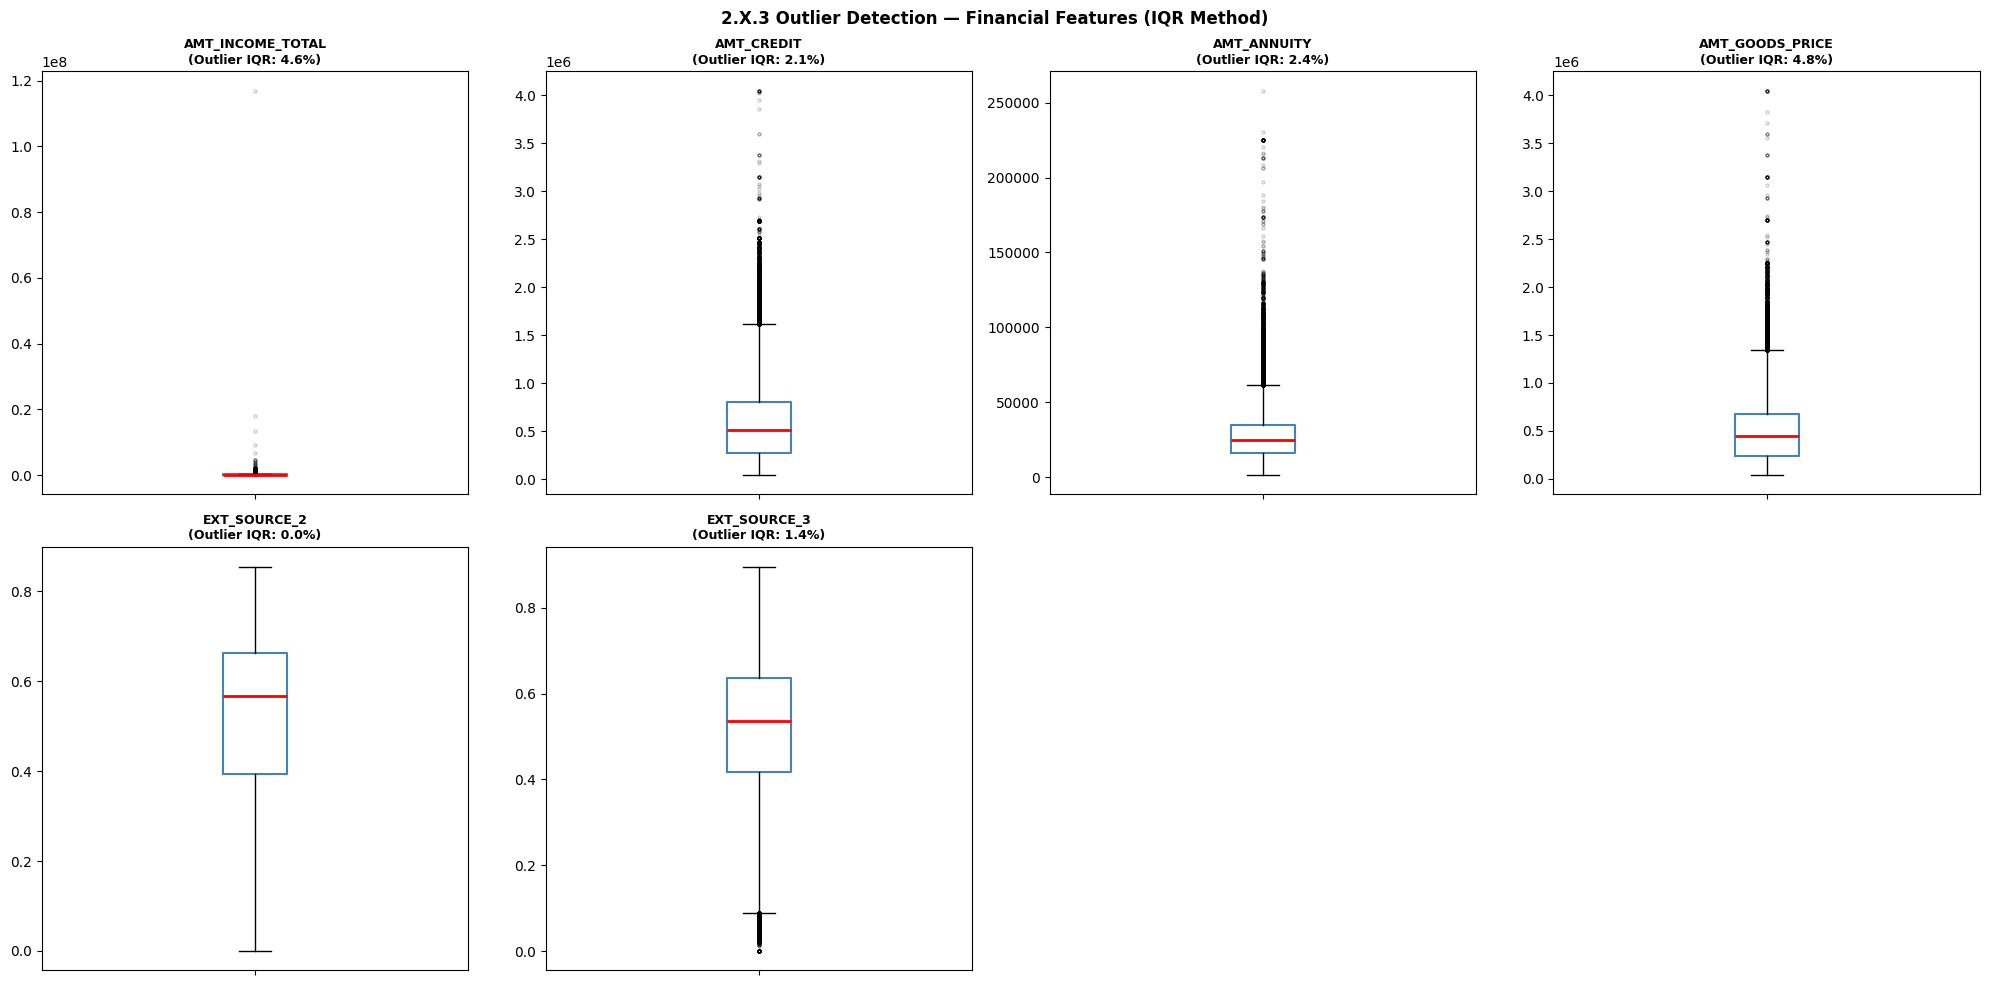

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# BƯỚC 3: PHÁT HIỆN VÀ XỬ LÝ OUTLIER (NGOẠI LAI)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("BƯỚC 3: XỬ LÝ OUTLIER — PHÂN BIỆT LỖI VÀ GIÁ TRỊ THẬT")
print("=" * 65)

# ── 3.1 Hàm phát hiện outlier bằng IQR và Z-score ──────────────────────────
def outlier_report(df, cols):
    """
    Báo cáo outlier dùng 2 phương pháp:
    - IQR: robust hơn, ít bị ảnh hưởng bởi extreme values
    - Z-score: giả định phân phối chuẩn (ít phù hợp với tài chính)
    """
    rows = []
    for col in cols:
        s = df[col].dropna()
        # IQR method
        Q1, Q3  = s.quantile(0.25), s.quantile(0.75)
        IQR     = Q3 - Q1
        lower   = Q1 - 1.5 * IQR
        upper   = Q3 + 1.5 * IQR
        n_iqr   = ((s < lower) | (s > upper)).sum()

        # Z-score method (|z| > 3)
        z_scores = (s - s.mean()) / (s.std() + 1e-9)
        n_zscore = (z_scores.abs() > 3).sum()

        rows.append({
            'Feature'     : col,
            'Q1'          : round(Q1, 2),
            'Q3'          : round(Q3, 2),
            'IQR_Lower'   : round(lower, 2),
            'IQR_Upper'   : round(upper, 2),
            'N_IQR'       : n_iqr,
            'Pct_IQR'     : round(n_iqr / len(df) * 100, 2),
            'N_Zscore'    : n_zscore,
            'Pct_Zscore'  : round(n_zscore / len(df) * 100, 2),
        })
    return pd.DataFrame(rows).sort_values('Pct_IQR', ascending=False)

# Chỉ phân tích các cột tài chính — nơi outlier có ý nghĩa nghiệp vụ
financial_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
                  'AMT_GOODS_PRICE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Lọc chỉ lấy cột tồn tại trong dữ liệu
financial_cols_exist = [c for c in financial_cols if c in app_processed.columns]

outlier_df = outlier_report(app_processed, financial_cols_exist)
print("\nBáo cáo Outlier (IQR & Z-score):")
print(outlier_df[['Feature','IQR_Lower','IQR_Upper','N_IQR','Pct_IQR','N_Zscore','Pct_Zscore']].to_string(index=False))

# ── 3.2 Visualize outlier với boxplot ───────────────────────────────────────
n_cols  = len(financial_cols_exist)
n_rows  = (n_cols + 3) // 4  # ceil division — tự tính số hàng cần thiết
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(financial_cols_exist):
    # Log transform để visualize rõ hơn (tài chính thường right-skewed)
    data = app_processed[col].dropna()
    axes[i].boxplot(data,
                    boxprops    = dict(color='steelblue', linewidth=1.5),
                    medianprops = dict(color='red', linewidth=2),
                    flierprops  = dict(marker='o', color='tomato', alpha=0.2, markersize=2))
    axes[i].set_title(f'{col}\n(Outlier IQR: {outlier_df.loc[outlier_df.Feature==col,"Pct_IQR"].values[0]:.1f}%)',
                      fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

# Ẩn các subplot thừa
for j in range(len(financial_cols_exist), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('2.X.3 Outlier Detection — Financial Features (IQR Method)', fontweight='bold')
plt.tight_layout()
plt.savefig('2X_outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# BƯỚC 3 (TIẾP): XỬ LÝ OUTLIER — CAPPING STRATEGY
# ══════════════════════════════════════════════════════════════════════════════

# ── 3.3 Chiến lược xử lý outlier theo từng biến ─────────────────────────────

# NGUYÊN TẮC trong tín dụng:
#   - Outlier tài chính (AMT_INCOME cao) = khách hàng VIP → KHÔNG xóa, KHÔNG cap
#   - Outlier kỹ thuật (giá trị không thể có) → xóa hoặc flag
#   - Outlier ảnh hưởng mô hình (skewed) → Winsorize/Cap hoặc log transform

# Các cột nên cap (Winsorize tại 1% và 99%)
# Lý do: AMT_ANNUITY và CREDIT_INCOME_RATIO có thể bị data entry error
cols_to_cap = ['AMT_ANNUITY', 'AMT_GOODS_PRICE']

print("Chiến lược xử lý outlier từng biến:")
print("-" * 60)

outlier_strategy = {
    'AMT_INCOME_TOTAL' : 'KEEP — High income = VIP customers, not errors',
    'AMT_CREDIT'       : 'KEEP — Large credit = legitimate corporate/SME loans',
    'AMT_ANNUITY'      : 'CAP at 99th percentile — may contain data entry errors',
    'AMT_GOODS_PRICE'  : 'CAP at 99th percentile — may contain data entry errors',
    'EXT_SOURCE_1'     : 'KEEP — Bounded [0,1] by design, no true outliers',
    'EXT_SOURCE_2'     : 'KEEP — Bounded [0,1] by design, no true outliers',
    'EXT_SOURCE_3'     : 'KEEP — Bounded [0,1] by design, no true outliers',
}

for col, strategy in outlier_strategy.items():
    if col in app_processed.columns:
        print(f"  {col:<25} → {strategy}")

# ── 3.4 Thực hiện Capping (Winsorization) ──────────────────────────────────
print("\nThực hiện Winsorization:")
for col in cols_to_cap:
    if col not in app_processed.columns:
        continue
    p01 = app_processed[col].quantile(0.01)  # Giới hạn dưới (1st percentile)
    p99 = app_processed[col].quantile(0.99)  # Giới hạn trên (99th percentile)

    # Đếm số hàng bị cap
    n_lower = (app_processed[col] < p01).sum()
    n_upper = (app_processed[col] > p99).sum()

    # clip() = giữ giá trị trong khoảng [p01, p99]
    app_processed[col] = app_processed[col].clip(lower=p01, upper=p99)
    print(f"  {col}: cap [{p01:,.0f}, {p99:,.0f}] — lower: {n_lower}, upper: {n_upper} rows affected")

# ── 3.5 Tóm tắt chất lượng dữ liệu sau xử lý ──────────────────────────────
print("\n" + "=" * 65)
print("TỔNG KẾT DATA QUALITY PIPELINE")
print("=" * 65)
print(f"  Shape ban đầu              : {app_train.shape}")
print(f"  Shape sau clean            : {app_processed.shape}")
print(f"  Hàng bị xóa (duplicate)    : {len(app_train) - len(app_processed):,}")
print(f"  Null còn lại               : {app_processed.isnull().sum().sum()}")
print(f"  Cột được impute (numeric)  : {len(num_impute)}")
print(f"  Cột được cap (outlier)     : {len(cols_to_cap)}")
print(f"\n  ✓ Dữ liệu đã sẵn sàng cho Feature Engineering")


Chiến lược xử lý outlier từng biến:
------------------------------------------------------------
  AMT_INCOME_TOTAL          → KEEP — High income = VIP customers, not errors
  AMT_CREDIT                → KEEP — Large credit = legitimate corporate/SME loans
  AMT_ANNUITY               → CAP at 99th percentile — may contain data entry errors
  AMT_GOODS_PRICE           → CAP at 99th percentile — may contain data entry errors
  EXT_SOURCE_2              → KEEP — Bounded [0,1] by design, no true outliers
  EXT_SOURCE_3              → KEEP — Bounded [0,1] by design, no true outliers

Thực hiện Winsorization:
  AMT_ANNUITY: cap [6,183, 70,006] — lower: 3075, upper: 3070 rows affected
  AMT_GOODS_PRICE: cap [67,500, 1,800,000] — lower: 2062, upper: 1431 rows affected

TỔNG KẾT DATA QUALITY PIPELINE
  Shape ban đầu              : (307511, 122)
  Shape sau clean            : (307511, 74)
  Hàng bị xóa (duplicate)    : 0
  Null còn lại               : 0
  Cột được impute (numeric)  : 16
  Cột đư

### 2.5 Outliers — Financial Features

         Feature  N_Outliers    Pct        Lower        Upper
 AMT_GOODS_PRICE       14728 4.7900 -423000.0000 1341000.0000
AMT_INCOME_TOTAL       14035 4.5600  -22500.0000  337500.0000
     AMT_ANNUITY        7504 2.4400  -10584.0000   61704.0000
      AMT_CREDIT        6562 2.1300 -537975.0000 1616625.0000
    EXT_SOURCE_1           0 0.0000      -0.1776       1.1866
    EXT_SOURCE_2           0 0.0000      -0.0143       1.0704
    EXT_SOURCE_3           0 0.0000      -0.0770       1.1167


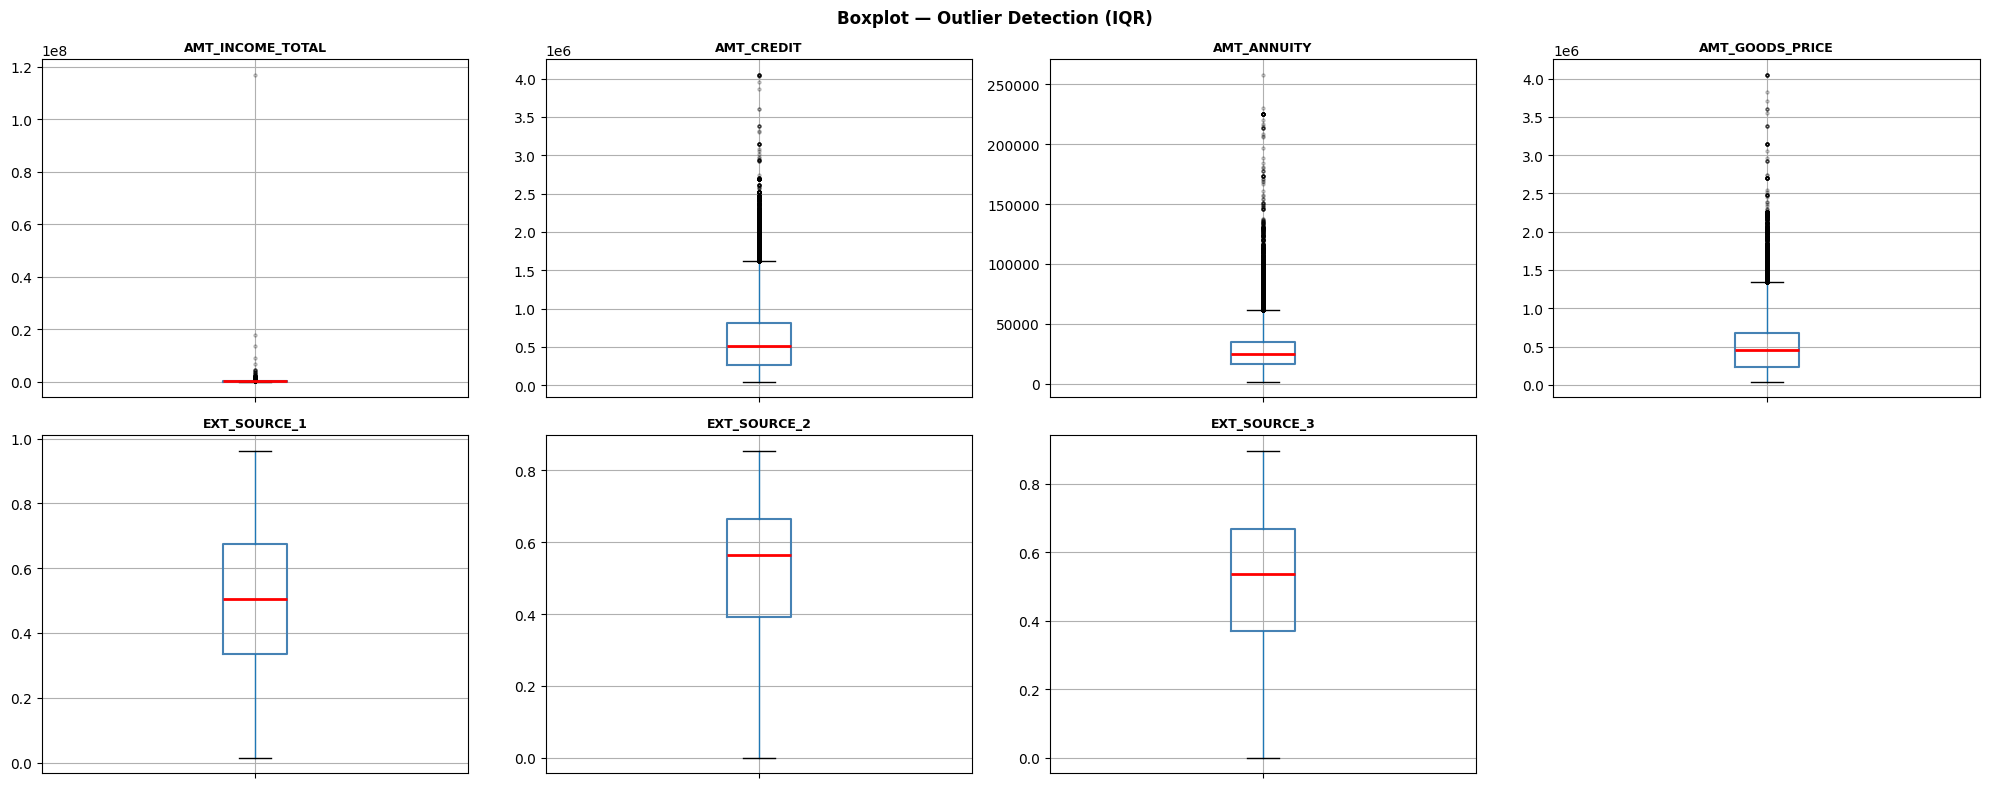

In [11]:
def detect_outliers_iqr(df, cols):
    rows = []
    for col in cols:
        s = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append({'Feature': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                     'Lower': lower, 'Upper': upper,
                     'N_Outliers': n_out, 'Pct': round(n_out/len(df)*100, 2)})
    return pd.DataFrame(rows).sort_values('Pct', ascending=False)

outlier_df = detect_outliers_iqr(app_train, cols_financial)
print(outlier_df[['Feature','N_Outliers','Pct','Lower','Upper']].to_string(index=False))

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(cols_financial):
    app_train.boxplot(column=col, ax=axes[i],
                      boxprops=dict(color='steelblue', linewidth=1.5),
                      medianprops=dict(color='red', linewidth=2),
                      flierprops=dict(marker='o', color='tomato', alpha=0.3, markersize=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)
for j in range(len(cols_financial), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot — Outlier Detection (IQR)', fontweight='bold')
plt.tight_layout()
plt.savefig('2.5_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


**Note:** Outliers in financial variables (AMT_INCOME_TOTAL, AMT_CREDIT) are **not errors** —  
they reflect real high-value customers. We **keep** them so the model learns the full distribution.

**Exception:** `DAYS_EMPLOYED = 365243` is a special code for non-employed (retired/students) — handle separately.

### 2.6 Correlation with Target

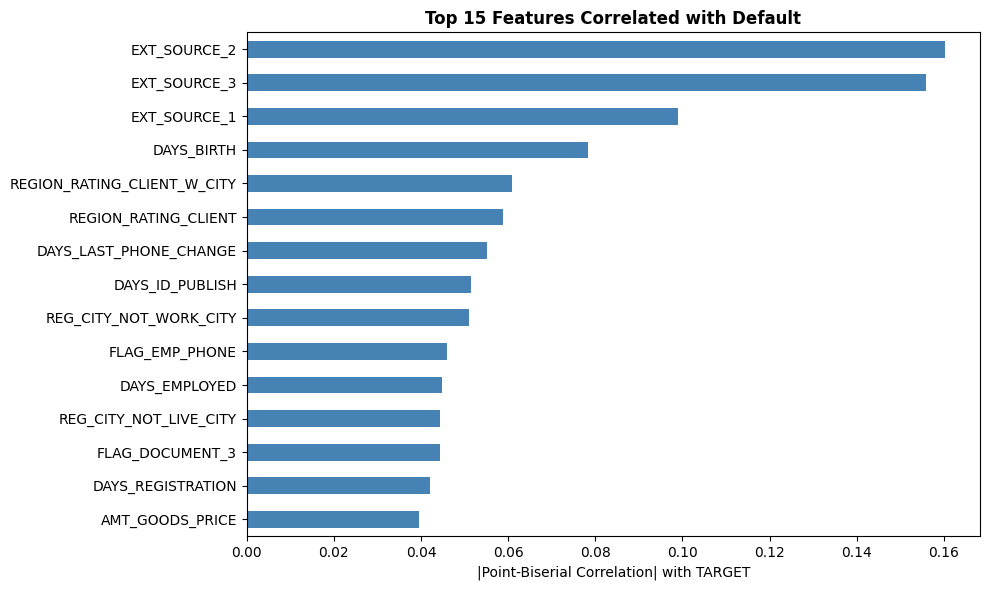

EXT_SOURCE_2                  0.1603
EXT_SOURCE_3                  0.1559
EXT_SOURCE_1                  0.0989
DAYS_BIRTH                    0.0782
REGION_RATING_CLIENT_W_CITY   0.0609
REGION_RATING_CLIENT          0.0589
DAYS_LAST_PHONE_CHANGE        0.0552
DAYS_ID_PUBLISH               0.0515
REG_CITY_NOT_WORK_CITY        0.0510
FLAG_EMP_PHONE                0.0460
DAYS_EMPLOYED                 0.0449
REG_CITY_NOT_LIVE_CITY        0.0444
FLAG_DOCUMENT_3               0.0443
DAYS_REGISTRATION             0.0420
AMT_GOODS_PRICE               0.0396


In [12]:
from scipy.stats import pointbiserialr

num_cols = app_train.select_dtypes('number').columns.drop(['TARGET','SK_ID_CURR'])
pbs_corr = {}
for col in num_cols:
    try:
        corr_val, _ = pointbiserialr(
            app_train[col].fillna(app_train[col].median()), app_train['TARGET'])
        pbs_corr[col] = abs(corr_val)
    except Exception:
        pass

corr_series = pd.Series(pbs_corr).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
corr_series.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('|Point-Biserial Correlation| with TARGET')
ax.set_title('Top 15 Features Correlated with Default', fontweight='bold')
plt.tight_layout()
plt.savefig('2.6_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_series.to_string())


## 3. Feature Engineering

In [13]:
# Ưu tiên dùng dữ liệu đã xử lý ở phần Data Quality.
# Nếu chạy riêng cell này mà chưa có app_processed, fallback về app_train.
df = app_processed.copy() if 'app_processed' in globals() else app_train.copy()

# ── 1. DAYS_EMPLOYED anomaly ────────────────────────────────────────────────
if 'DAYS_EMPLOYED' in df.columns:
    if 'DAYS_EMPLOYED_ANOMALY' not in df.columns:
        n_anomaly = (df['DAYS_EMPLOYED'] == 365243).sum()
        print(f"DAYS_EMPLOYED anomaly (365243): {n_anomaly:,} rows ({n_anomaly/len(df)*100:.1f}%)")
        if 'TARGET' in df.columns:
            print(f"  Default rate anomaly : {df.loc[df['DAYS_EMPLOYED']==365243,'TARGET'].mean()*100:.2f}%")
            print(f"  Default rate normal  : {df.loc[df['DAYS_EMPLOYED']!=365243,'TARGET'].mean()*100:.2f}%")
        df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
        df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    else:
        print("DAYS_EMPLOYED anomaly flag đã có từ bước Data Quality.")

# ── 2. Age & Employment ─────────────────────────────────────────────────────
if 'DAYS_BIRTH' in df.columns:
    df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365

if 'DAYS_EMPLOYED' in df.columns:
    df['EMPLOY_YEARS'] = -df['DAYS_EMPLOYED'] / 365

# ── 3. Financial ratios ─────────────────────────────────────────────────────
safe_income = df['AMT_INCOME_TOTAL'].replace(0, np.nan) if 'AMT_INCOME_TOTAL' in df.columns else np.nan

if {'AMT_CREDIT', 'AMT_INCOME_TOTAL'}.issubset(df.columns):
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / safe_income

if {'AMT_ANNUITY', 'AMT_INCOME_TOTAL'}.issubset(df.columns):
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / safe_income

if {'AMT_CREDIT', 'AMT_GOODS_PRICE'}.issubset(df.columns):
    df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE'].replace(0, np.nan)

if {'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS'}.issubset(df.columns):
    fam_size = df['CNT_FAM_MEMBERS'].replace(0, np.nan).fillna(1)
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / fam_size

# ── 4. EXT_SOURCE composite ─────────────────────────────────────────────────
ext_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in df.columns]
if ext_cols:
    df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
    df['EXT_SOURCE_MIN']  = df[ext_cols].min(axis=1)
    df['EXT_SOURCE_PROD'] = df[ext_cols].prod(axis=1, min_count=1)

print("\n✓ app_train/app_processed features engineered")


DAYS_EMPLOYED anomaly flag đã có từ bước Data Quality.

✓ app_train/app_processed features engineered


In [14]:
# ── Bureau aggregations ─────────────────────────────────────────────────────
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT      = ('SK_ID_BUREAU',       'count'),
    BUREAU_ACTIVE_COUNT    = ('CREDIT_ACTIVE',      lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT    = ('CREDIT_ACTIVE',      lambda x: (x == 'Closed').sum()),
    BUREAU_OVERDUE_MEAN    = ('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_OVERDUE_MAX     = ('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_DEBT_MEAN       = ('AMT_CREDIT_SUM_DEBT','mean'),
    BUREAU_DEBT_SUM        = ('AMT_CREDIT_SUM_DEBT','sum'),
    BUREAU_CREDIT_SUM      = ('AMT_CREDIT_SUM',     'sum'),
).reset_index()

df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')

# ── Previous application aggregations ───────────────────────────────────────
prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT         = ('SK_ID_PREV',          'count'),
    PREV_APPROVED_COUNT    = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT     = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_AMT_CREDIT_MEAN   = ('AMT_CREDIT',         'mean'),
    PREV_AMT_ANNUITY_MEAN  = ('AMT_ANNUITY',        'mean'),
).reset_index()

prev_agg['PREV_APPROVAL_RATE'] = (
    prev_agg['PREV_APPROVED_COUNT'] / prev_agg['PREV_APP_COUNT'].replace(0, np.nan)
).fillna(0)

df = df.merge(prev_agg, on='SK_ID_CURR', how='left')

# ── Installments: repayment behavior ────────────────────────────────────────
# Home Credit dùng ngày âm: actual payment muộn hơn schedule sẽ "ít âm hơn".
# Vì vậy late days đúng = DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT, không phải ngược lại.
installments = installments.copy()
installments['DAYS_LATE'] = (
    installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
).clip(lower=0)

instal_agg = installments.groupby('SK_ID_CURR').agg(
    INSTAL_COUNT           = ('SK_ID_PREV',     'count'),
    INSTAL_DAYS_LATE_MEAN  = ('DAYS_LATE',      'mean'),
    INSTAL_DAYS_LATE_MAX   = ('DAYS_LATE',      'max'),
    INSTAL_LATE_RATE       = ('DAYS_LATE',      lambda x: (x > 0).mean()),
    INSTAL_AMT_PAYMENT_SUM = ('AMT_PAYMENT',    'sum'),
    INSTAL_AMT_INSTAL_SUM  = ('AMT_INSTALMENT', 'sum'),
).reset_index()

instal_agg['INSTAL_PAYMENT_RATIO'] = (
    instal_agg['INSTAL_AMT_PAYMENT_SUM'] /
    instal_agg['INSTAL_AMT_INSTAL_SUM'].replace(0, np.nan)
).fillna(0)

df = df.merge(instal_agg, on='SK_ID_CURR', how='left')

print(f"Master dataset: {df.shape}")
df_master = df.copy()


Master dataset: (307511, 104)




**Các ratio tài chính được tạo:**

| Feature | Công thức | Tại sao hữu ích |
|---------|-----------|-----------------|
| `CREDIT_INCOME_RATIO` | Credit / Income | Khoản vay gấp bao nhiêu lần thu nhập? |
| `ANNUITY_INCOME_RATIO` | Annuity / (Income/12) | Tương tự DTI — gánh nặng trả nợ hàng tháng |
| `CREDIT_GOODS_RATIO` | Credit / Goods Price | Vay nhiều hơn giá trị tài sản? (LTV cao = rủi ro) |
| `EXT_SOURCE_MIN` | min(EXT1, EXT2, EXT3) | Điểm yếu nhất — ngân hàng quan tâm worst case |

**Bureau aggregations** từ lịch sử tín dụng là signal **mạnh nhất**:
- `BUREAU_OVERDUE_MAX > 0` → từng trễ hạn → default rate tăng đáng kể
- `BUREAU_ACTIVE_COUNT` cao → đang vay nhiều nơi → overleverage risk


## 4. Giám Sát Rủi Ro Danh Mục (Portfolio Risk KPI)

Phần này xây dựng toàn bộ pipeline giám sát rủi ro danh mục tín dụng phục vụ vận hành thực tế:

| Module | Noi dung | Nguoi dung |
|--------|----------|------------|
| 4.1 | Phân loại DPD & phân tích theo segment (loan type, income type) | Credit Risk Officer |
| 4.2 | Tỷ lệ Delinquency hàng tháng — theo danh mục và segment | Portfolio Manager |
| 4.3 | Vintage Curves — cohort theo quý, cộng dồn theo tuổi khoản vay | Chief Risk Officer |
| 4.4 | Roll Rate Matrix & Early Warning Signals | Collection Team |
| 4.5 | Tổng hợp KPI danh mục (RAR, EL, DTI) | Ban Giám Đốc |

**Luồng dữ liệu:**
```
bureau_balance --> DPD hàng tháng --> Roll Rate --> Vintage --> Early Warning
app_train      --> Segment breakdown --> DPD by loan/income type
```

### 4.1 Phân Loại DPD và Phân Tích theo Segment

**Days Past Due (DPD)** là thước đo trung tâm của rủi ro tín dụng. Phần này không chỉ tính phân phối tổng thể mà còn **breakdown theo loan type và income type** để xác định segment nào đang có rủi ro cao hơn.

STATUS distribution trong bureau_balance:
STATUS
0     7499507
1      242347
2       23419
3        8924
4        5847
5       62406
C    13646993
X     5810482

STATUS chưa map: Không có

PHAN PHOI DPD TOAN DANH MUC
                        So luong  Ty le (%)
DPD_BUCKET                                 
Current (0 DPD)           595494    34.6900
DPD 1-30                   84072     4.9000
DPD 31-60                   7279     0.4200
DPD 61-90                   1891     0.1100
DPD 90+                     5409     0.3200
Status unknown only        80209     4.6700
No bureau_balance data    942074    54.8900

NPL Rate trên toàn bộ bureau         : 0.32%
NPL Rate trên nhóm có bureau_balance : 0.78%
DPD > 0 trên nhóm có bureau_balance  : 14.21%
PAR30 / DPD 31+ trên nhóm có data    : 2.10%
No bureau_balance data               : 54.89%


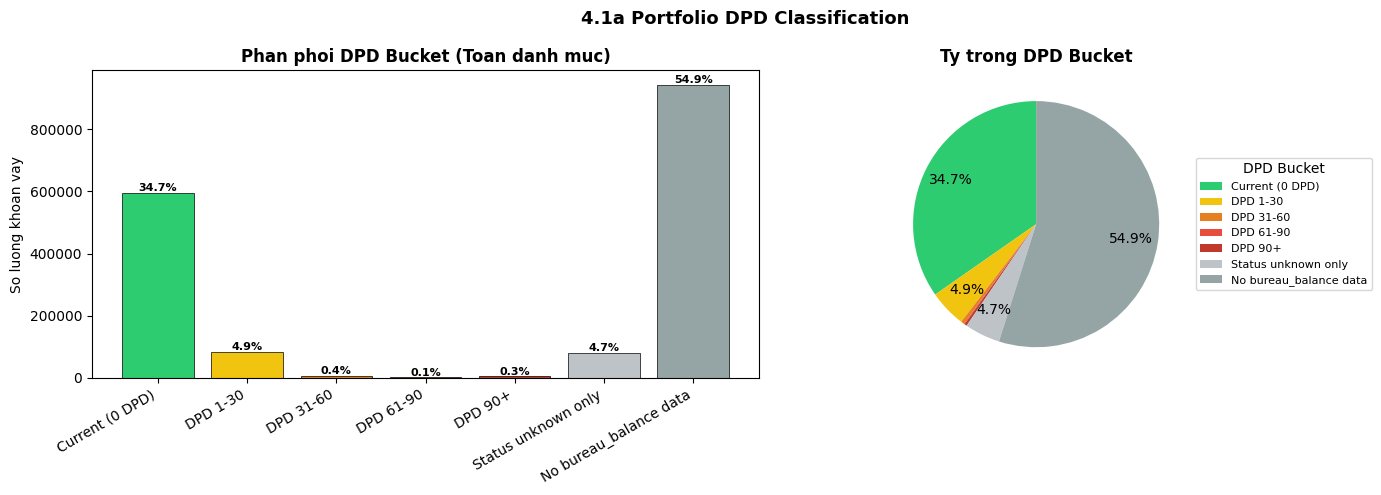

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.1 PHAN LOAI DPD — PORTFOLIO + SEGMENT BREAKDOWN
# ══════════════════════════════════════════════════════════════════════════════
# bureau_balance.STATUS:
#   0 = Current / no DPD
#   1 = DPD 1-30
#   2 = DPD 31-60
#   3 = DPD 61-90
#   4,5 = DPD 90+
#   C = Closed
#   X = Unknown / no status

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Buoc 1: Map STATUS sang so ngay DPD ─────────────────────────────────────
status_map_days = {
    '0': 0,
    '1': 15,
    '2': 45,
    '3': 75,
    '4': 105,
    '5': 150,
    'C': 0,       # closed loan, không phải delinquent
    'X': np.nan   # unknown status
}

bureau_bal_work = bureau_bal.copy()
bureau_bal_work['STATUS'] = bureau_bal_work['STATUS'].astype(str)
bureau_bal_work['DPD_DAYS'] = bureau_bal_work['STATUS'].map(status_map_days)

# ── Data quality check cho STATUS ───────────────────────────────────────────
print("STATUS distribution trong bureau_balance:")
print(bureau_bal_work['STATUS'].value_counts(dropna=False).sort_index().to_string())

unmapped_status = sorted(set(bureau_bal_work['STATUS'].dropna().unique()) - set(status_map_days.keys()))
print(f"\nSTATUS chưa map: {unmapped_status if unmapped_status else 'Không có'}")

# ── Buoc 2: Max DPD per loan ────────────────────────────────────────────────
max_dpd_per_loan = (
    bureau_bal_work
    .groupby('SK_ID_BUREAU')['DPD_DAYS']
    .max()
    .reset_index(name='MAX_DPD')
)

bureau_with_dpd = bureau.merge(max_dpd_per_loan, on='SK_ID_BUREAU', how='left')
bb_ids = set(bureau_bal_work['SK_ID_BUREAU'].unique())
bureau_with_dpd['HAS_BUREAU_BALANCE'] = bureau_with_dpd['SK_ID_BUREAU'].isin(bb_ids)

# ── Buoc 3: Ham phan loai DPD bucket ────────────────────────────────────────
DPD_ORDER  = [
    'Current (0 DPD)',
    'DPD 1-30',
    'DPD 31-60',
    'DPD 61-90',
    'DPD 90+',
    'Status unknown only',
    'No bureau_balance data'
]
COLORS_DPD = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#bdc3c7', '#95a5a6']

def classify_dpd_row(row):
    if not row['HAS_BUREAU_BALANCE']:
        return 'No bureau_balance data'

    dpd = row['MAX_DPD']
    if pd.isna(dpd):
        return 'Status unknown only'
    if dpd == 0:
        return 'Current (0 DPD)'
    if dpd <= 30:
        return 'DPD 1-30'
    if dpd <= 60:
        return 'DPD 31-60'
    if dpd <= 90:
        return 'DPD 61-90'
    return 'DPD 90+'

bureau_with_dpd['DPD_BUCKET'] = bureau_with_dpd.apply(classify_dpd_row, axis=1)

# ── Buoc 4: Phan phoi DPD toan danh muc ─────────────────────────────────────
dpd_dist = (bureau_with_dpd['DPD_BUCKET']
            .value_counts()
            .reindex(DPD_ORDER, fill_value=0))

total   = dpd_dist.sum()
dpd_pct = (dpd_dist / total * 100).round(2)

known_buckets = ['Current (0 DPD)', 'DPD 1-30', 'DPD 31-60', 'DPD 61-90', 'DPD 90+']
known_total = dpd_dist[known_buckets].sum()

print("\n" + "=" * 70)
print("PHAN PHOI DPD TOAN DANH MUC")
print("=" * 70)
df_print = pd.DataFrame({'So luong': dpd_dist, 'Ty le (%)': dpd_pct})
print(df_print.to_string())

npl_all = dpd_dist['DPD 90+'] / total * 100 if total else 0
npl_known = dpd_dist['DPD 90+'] / known_total * 100 if known_total else 0

# DPD > 0 và PAR30 đúng nghĩa DPD 31+
dpd_gt0_known = dpd_dist[['DPD 1-30', 'DPD 31-60', 'DPD 61-90', 'DPD 90+']].sum() / known_total * 100 if known_total else 0
par30_known = dpd_dist[['DPD 31-60', 'DPD 61-90', 'DPD 90+']].sum() / known_total * 100 if known_total else 0

print(f"\nNPL Rate trên toàn bộ bureau         : {npl_all:.2f}%")
print(f"NPL Rate trên nhóm có bureau_balance : {npl_known:.2f}%")
print(f"DPD > 0 trên nhóm có bureau_balance  : {dpd_gt0_known:.2f}%")
print(f"PAR30 / DPD 31+ trên nhóm có data    : {par30_known:.2f}%")
print(f"No bureau_balance data               : {dpd_pct.get('No bureau_balance data', 0):.2f}%")

# ── Bieu do tong quan ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(len(DPD_ORDER)), dpd_dist.values, color=COLORS_DPD, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(DPD_ORDER)))
axes[0].set_xticklabels(DPD_ORDER, rotation=30, ha='right')
axes[0].set_ylabel('So luong khoan vay')
axes[0].set_title('Phan phoi DPD Bucket (Toan danh muc)', fontweight='bold')

for i, (v, p) in enumerate(zip(dpd_dist.values, dpd_pct.values)):
    if v > 0:
        axes[0].text(i, v + total*0.003, f'{p:.1f}%', ha='center', fontsize=8, fontweight='bold')

# Pie: bỏ label trực tiếp để không bị đè chữ ở các bucket nhỏ
wedges, texts, autotexts = axes[1].pie(
    dpd_dist.values,
    colors=COLORS_DPD,
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 2 else '',
    startangle=90,
    pctdistance=0.78
)
axes[1].legend(wedges, DPD_ORDER, title='DPD Bucket',
               loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
axes[1].set_title('Ty trong DPD Bucket', fontweight='bold')

plt.suptitle('4.1a Portfolio DPD Classification', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('4.1a_dpd_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()


DPD Breakdown theo Loan Type:
        Segment  Tong khoan  NPL Count  NPL Rate (%)  PAR30 Rate (%)
     Cash loans     1339738       4292        0.3200          5.0500
Revolving loans      125587         11        0.0100          0.2500

DPD Breakdown theo Income Type:
             Segment  Tong khoan  NPL Count  NPL Rate (%)  PAR30 Rate (%)
Commercial associate      336229       1068        0.3200          4.8100
             Working      749061       2226        0.3000          4.6700
           Pensioner      256741        718        0.2800          4.1600
       State servant      123200        291        0.2400          4.9500
     Maternity leave           1          0        0.0000          0.0000
         Businessman          13          0        0.0000          0.0000
             Student          64          0        0.0000          3.1200
          Unemployed          16          0        0.0000          0.0000


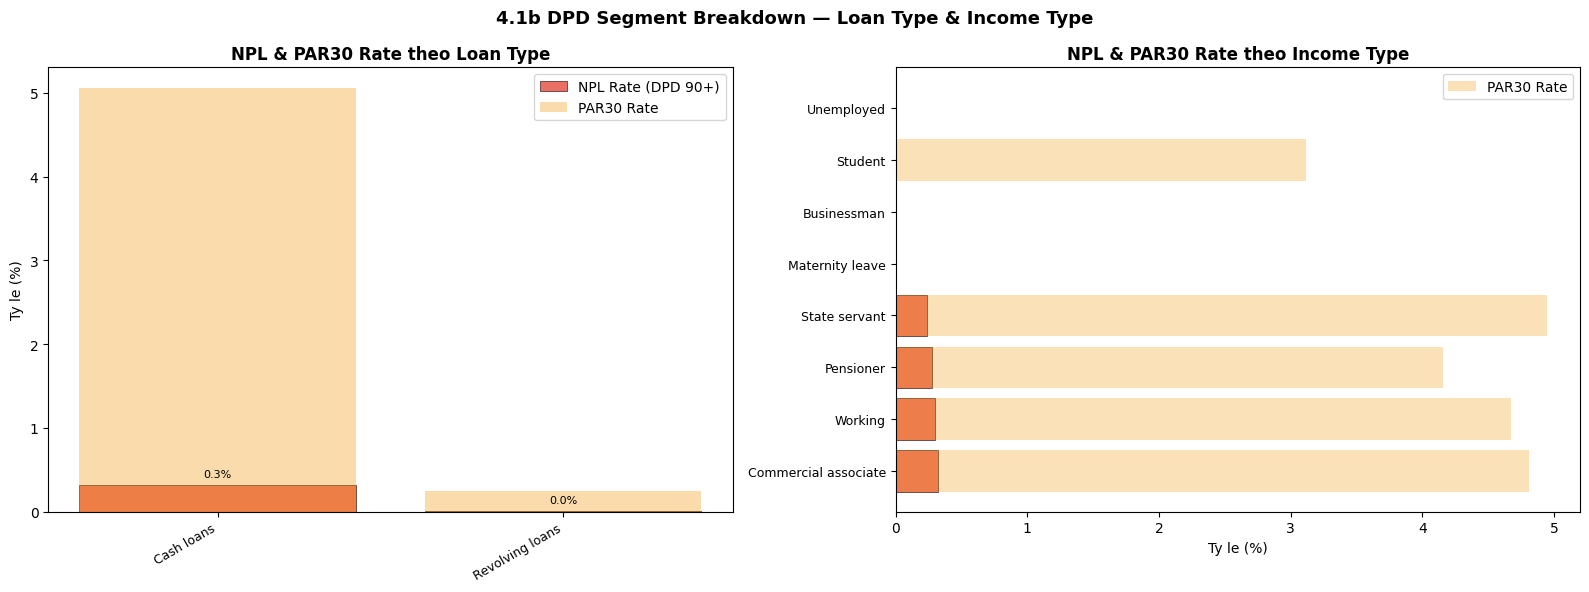

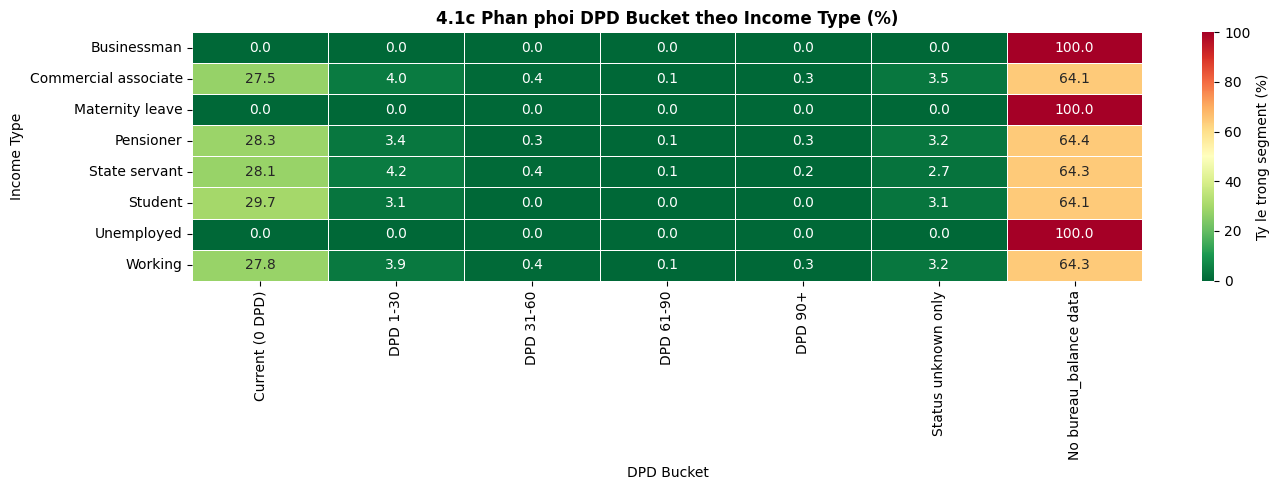

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.1b DPD BREAKDOWN THEO SEGMENT (LOAN TYPE & INCOME TYPE)
# ══════════════════════════════════════════════════════════════════════════════
# Ket hop bureau_with_dpd voi app_train de co thong tin segment

bureau_seg = bureau_with_dpd.merge(
    app_train[['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'TARGET']],
    on='SK_ID_CURR', how='left'
)

# ── Ham tinh NPL Rate va PAR30 per segment ──────────────────────────────────
def npl_by_segment(df, seg_col, top_n=10):
    df = df.dropna(subset=[seg_col])
    result = []
    for val, grp in df.groupby(seg_col):
        total_loans = len(grp)
        npl_count   = (grp['DPD_BUCKET'] == 'DPD 90+').sum()
        par30_count = grp['DPD_BUCKET'].isin(['DPD 1-30','DPD 31-60','DPD 61-90','DPD 90+']).sum()
        result.append({
            'Segment'      : val,
            'Tong khoan'   : total_loans,
            'NPL Count'    : npl_count,
            'NPL Rate (%)' : round(npl_count  / total_loans * 100, 2) if total_loans > 0 else 0,
            'PAR30 Rate (%)': round(par30_count / total_loans * 100, 2) if total_loans > 0 else 0,
        })
    return (pd.DataFrame(result)
              .sort_values('NPL Rate (%)', ascending=False)
              .head(top_n)
              .reset_index(drop=True))

dpd_by_loan_type   = npl_by_segment(bureau_seg, 'NAME_CONTRACT_TYPE')
dpd_by_income_type = npl_by_segment(bureau_seg, 'NAME_INCOME_TYPE', top_n=8)

print("DPD Breakdown theo Loan Type:")
print(dpd_by_loan_type.to_string(index=False))
print("\nDPD Breakdown theo Income Type:")
print(dpd_by_income_type.to_string(index=False))

# ── Bieu do so sanh segment ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x1 = range(len(dpd_by_loan_type))
bars1 = axes[0].bar(x1, dpd_by_loan_type['NPL Rate (%)'], color='#e74c3c',
                    alpha=0.8, label='NPL Rate (DPD 90+)', edgecolor='black', linewidth=0.5)
axes[0].bar(x1, dpd_by_loan_type['PAR30 Rate (%)'], color='#f39c12',
            alpha=0.35, label='PAR30 Rate', edgecolor='none')
axes[0].set_xticks(x1)
axes[0].set_xticklabels(dpd_by_loan_type['Segment'], rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Ty le (%)')
axes[0].set_title('NPL & PAR30 Rate theo Loan Type', fontweight='bold')
axes[0].legend()
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{h:.1f}%',
                 ha='center', fontsize=8)

x2 = range(len(dpd_by_income_type))
bars2 = axes[1].barh(x2, dpd_by_income_type['NPL Rate (%)'],
                     color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].barh(x2, dpd_by_income_type['PAR30 Rate (%)'],
             color='#f39c12', alpha=0.3, label='PAR30 Rate')
axes[1].set_yticks(x2)
axes[1].set_yticklabels(dpd_by_income_type['Segment'], fontsize=9)
axes[1].set_xlabel('Ty le (%)')
axes[1].set_title('NPL & PAR30 Rate theo Income Type', fontweight='bold')
axes[1].legend()

plt.suptitle('4.1b DPD Segment Breakdown — Loan Type & Income Type', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('4.1b_dpd_segment.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Heatmap DPD bucket theo Income Type ─────────────────────────────────────
pivot_income = (bureau_seg
    .dropna(subset=['NAME_INCOME_TYPE'])
    .groupby(['NAME_INCOME_TYPE','DPD_BUCKET'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=DPD_ORDER, fill_value=0))

pivot_pct = pivot_income.div(pivot_income.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_pct.round(1), annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Ty le trong segment (%)'})
ax.set_title('4.1c Phan phoi DPD Bucket theo Income Type (%)', fontweight='bold')
ax.set_xlabel('DPD Bucket')
ax.set_ylabel('Income Type')
plt.tight_layout()
plt.savefig('4.1c_dpd_heatmap_income.png', dpi=150, bbox_inches='tight')
plt.show()

---

**Giải thích DPD Bucket theo tiêu chuẩn ngành:**

| Bucket | Y nghia nghiep vu | Hanh dong | Phan loai Basel |
|--------|-------------------|-----------|-----------------|
| Current (0 DPD) | Trả đúng hạn | Giữ nguyên — có thể upsell | Pass |
| DPD 1-30 | Trễ nhẹ | Nhắc nợ tự động (SMS/email) | Watch |
| DPD 31-60 | Trễ trung bình | Gọi điện trực tiếp | Substandard |
| DPD 61-90 | Trễ nặng | Đàm phán cơ cấu lại nợ | Doubtful |
| DPD 90+ | Nợ xấu (NPL) | Chuyển thu hồi nợ / trích lập dự phòng 100% LGD | Loss |

**Segment breakdown giúp xác định:**
- Loan type nào đang có NPL rate cao bất thường → điều chỉnh chính sách phê duyệt
- Income type nào có PAR30 tăng → tăng cường monitoring, giảm hạn mức

### 4.2 Tỷ Lệ Delinquency Hàng Tháng theo Segment

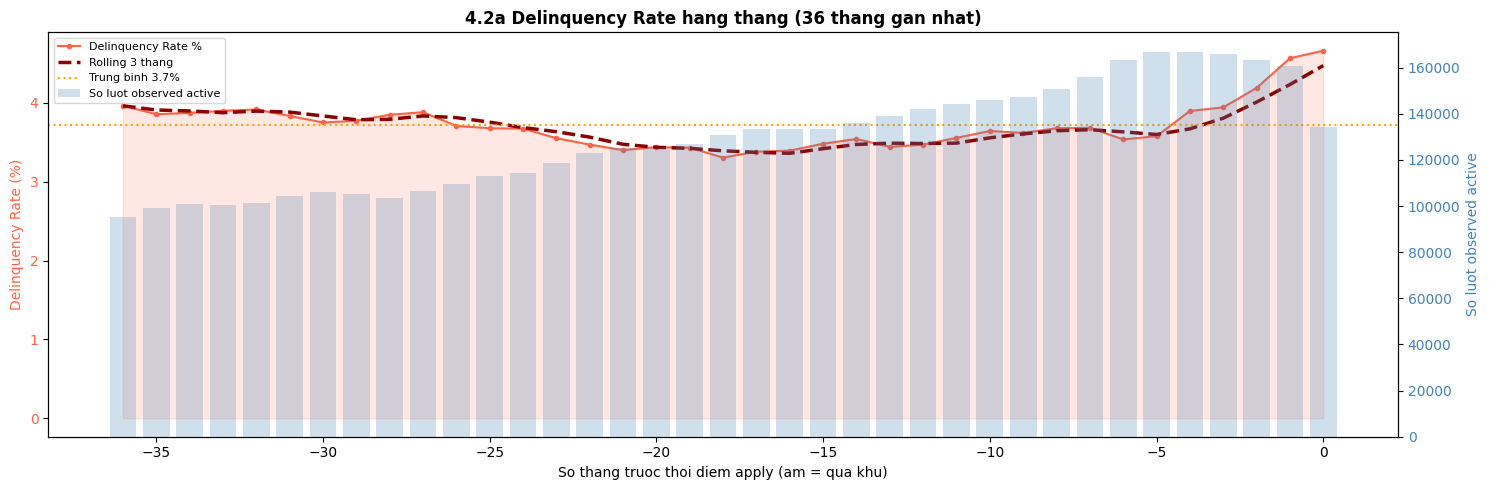

Thang delinquency cao nhat trong 36 thang gan nhat:
MONTHS_BALANCE         0.0000
DELINQ_RATE_PCT        4.6585
LOAN_COUNT        134336.0000


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.2 TY LE DELINQUENCY HANG THANG — TONG DANH MUC & THEO SEGMENT
# ══════════════════════════════════════════════════════════════════════════════
# Delinquency Rate = % lượt active observed bị trễ / tổng lượt active observed.
# Không đưa C/X vào mẫu số vì C = closed, X = unknown → sẽ làm rate bị thấp giả.

valid_observed_status = ['0', '1', '2', '3', '4', '5']

bureau_bal_work['STATUS'] = bureau_bal_work['STATUS'].astype(str)
bureau_bal_work['IS_OBSERVED_ACTIVE'] = bureau_bal_work['STATUS'].isin(valid_observed_status).astype(int)
bureau_bal_work['IS_DELINQUENT'] = bureau_bal_work['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

bureau_bal_observed = bureau_bal_work[bureau_bal_work['IS_OBSERVED_ACTIVE'] == 1].copy()

# ── 4.2a Delinquency rate tong danh muc theo thang ──────────────────────────
monthly_delinq = (
    bureau_bal_observed
    .groupby('MONTHS_BALANCE')['IS_DELINQUENT']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'DELINQ_RATE', 'count': 'LOAN_COUNT'})
    .sort_values('MONTHS_BALANCE')
)

monthly_36 = monthly_delinq[monthly_delinq['MONTHS_BALANCE'] >= -36].copy()
monthly_36['DELINQ_RATE_PCT'] = monthly_36['DELINQ_RATE'] * 100
monthly_36['DELINQ_ROLL3']    = monthly_36['DELINQ_RATE_PCT'].rolling(3, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(15, 5))
ax2 = ax1.twinx()

ax1.fill_between(monthly_36['MONTHS_BALANCE'], monthly_36['DELINQ_RATE_PCT'],
                 alpha=0.15, color='tomato')
ax1.plot(monthly_36['MONTHS_BALANCE'], monthly_36['DELINQ_RATE_PCT'],
         color='tomato', linewidth=1.5, marker='o', markersize=3, label='Delinquency Rate %')
ax1.plot(monthly_36['MONTHS_BALANCE'], monthly_36['DELINQ_ROLL3'],
         color='darkred', linewidth=2.5, linestyle='--', label='Rolling 3 thang')
ax2.bar(monthly_36['MONTHS_BALANCE'], monthly_36['LOAN_COUNT'],
        color='steelblue', alpha=0.25, label='So luot observed active')

avg_delinq = monthly_36['DELINQ_RATE_PCT'].mean()
ax1.axhline(y=avg_delinq, color='orange', linestyle=':', linewidth=1.5,
            label=f'Trung binh {avg_delinq:.1f}%')

ax1.set_xlabel('So thang truoc thoi diem apply (am = qua khu)')
ax1.set_ylabel('Delinquency Rate (%)', color='tomato')
ax2.set_ylabel('So luot observed active', color='steelblue')
ax1.tick_params(axis='y', labelcolor='tomato')
ax2.tick_params(axis='y', labelcolor='steelblue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax1.set_title('4.2a Delinquency Rate hang thang (36 thang gan nhat)', fontweight='bold')

plt.tight_layout()
plt.savefig('4.2a_monthly_delinquency.png', dpi=150, bbox_inches='tight')
plt.show()

idx_max = monthly_36['DELINQ_RATE_PCT'].idxmax()
print("Thang delinquency cao nhat trong 36 thang gan nhat:")
print(monthly_36.loc[idx_max, ['MONTHS_BALANCE', 'DELINQ_RATE_PCT', 'LOAN_COUNT']].to_string())


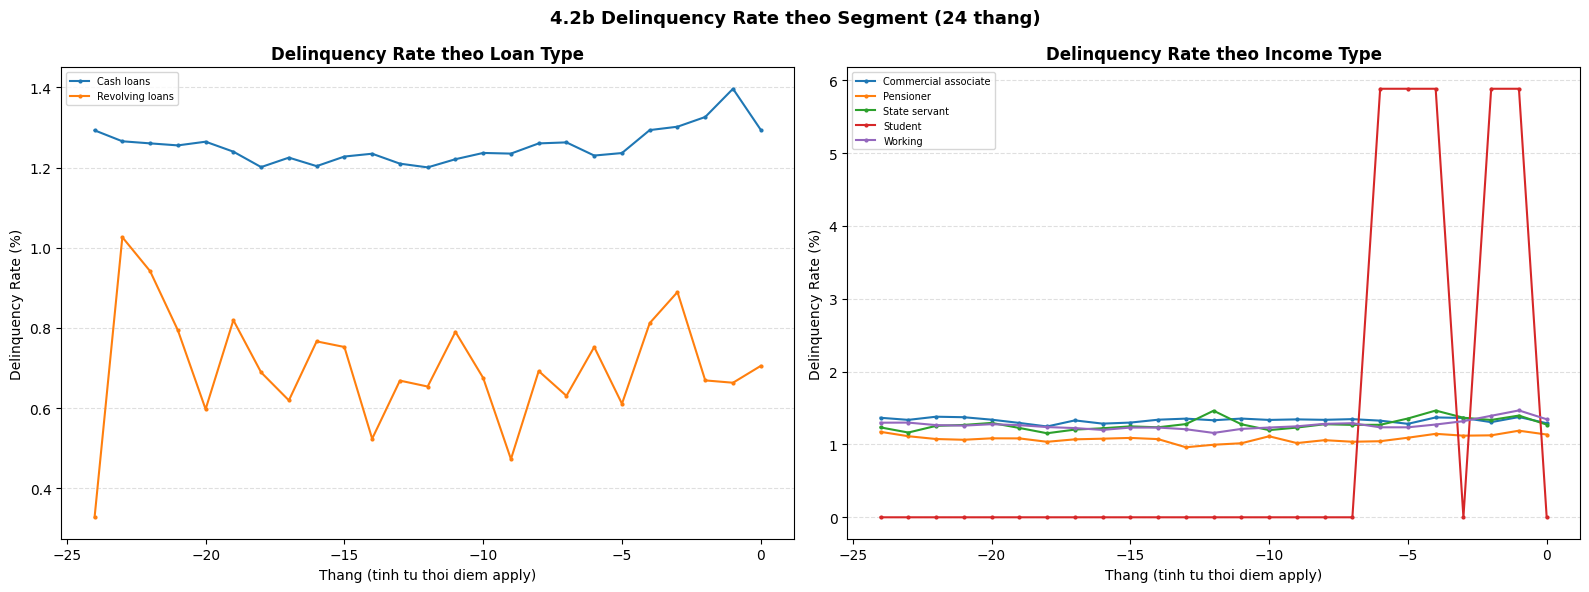

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.2b DELINQUENCY RATE THEO SEGMENT — Loan Type & Income Type
# ══════════════════════════════════════════════════════════════════════════════
# Muc tieu: xac dinh segment nao dang co delinquency tang som hon portfolio

bureau_bal_seg = (bureau_bal_work
    .merge(bureau[['SK_ID_BUREAU','SK_ID_CURR']], on='SK_ID_BUREAU', how='left')
    .merge(app_train[['SK_ID_CURR','NAME_CONTRACT_TYPE','NAME_INCOME_TYPE']],
           on='SK_ID_CURR', how='left'))

bureau_bal_seg_24 = bureau_bal_seg[bureau_bal_seg['MONTHS_BALANCE'] >= -24].copy()

def delinq_by_seg(df, seg_col):
    return (df
        .dropna(subset=[seg_col])
        .groupby([seg_col, 'MONTHS_BALANCE'])['IS_DELINQUENT']
        .mean()
        .reset_index()
        .rename(columns={'IS_DELINQUENT': 'DELINQ_RATE'})
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, seg_col, title in [
    (axes[0], 'NAME_CONTRACT_TYPE', 'Loan Type'),
    (axes[1], 'NAME_INCOME_TYPE',   'Income Type')
]:
    seg_data = delinq_by_seg(bureau_bal_seg_24, seg_col)
    for seg_val, grp in seg_data.groupby(seg_col):
        grp_s = grp.sort_values('MONTHS_BALANCE')
        ax.plot(grp_s['MONTHS_BALANCE'], grp_s['DELINQ_RATE'] * 100,
                marker='o', markersize=2, linewidth=1.5, label=str(seg_val)[:30])
    ax.set_xlabel('Thang (tinh tu thoi diem apply)')
    ax.set_ylabel('Delinquency Rate (%)')
    ax.set_title(f'Delinquency Rate theo {title}', fontweight='bold')
    ax.legend(fontsize=7, loc='best')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('4.2b Delinquency Rate theo Segment (24 thang)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('4.2b_delinquency_segment.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Vintage Curves — Phân Tích Hiệu Suất theo Cohort

**Vintage analysis** nhóm các khoản vay theo **quý phát sinh** (origination quarter) và theo dõi delinquency rate tích lũy theo tuổi của khoản vay.


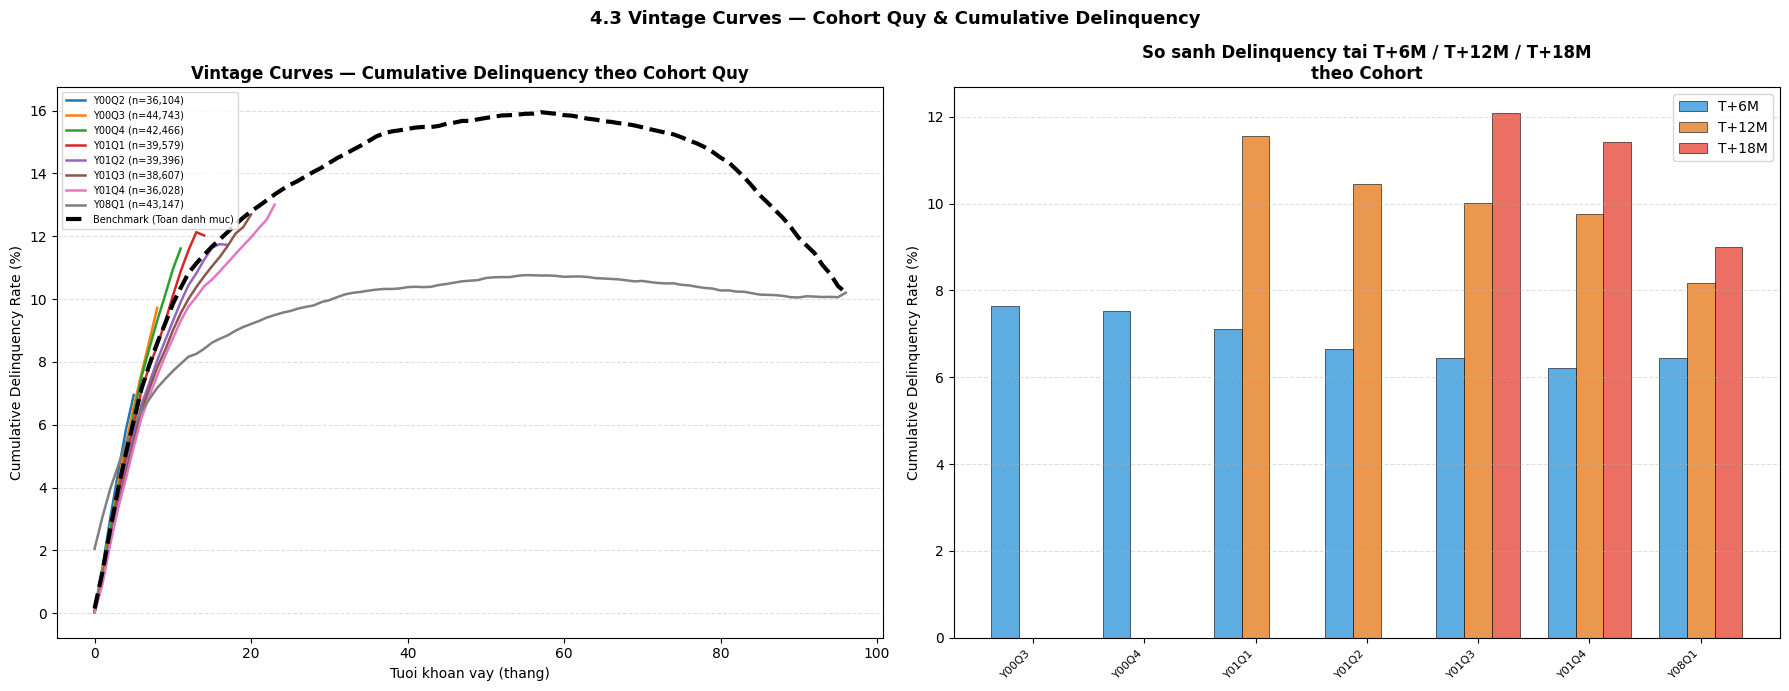


Xep hang cohort theo Cumulative Delinquency tai T+12M:
         T+12M
COHORT        
Y01Q1  11.5500
Y01Q2  10.4400
Y01Q3  10.0000
Y01Q4   9.7600
Y08Q1   8.1600

Cohort rui ro cao nhat : Y01Q1, T+12M Delinquency = 11.55%


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.3 VINTAGE CURVES — COHORT THEO QUY, CUMULATIVE DELINQUENCY
# ══════════════════════════════════════════════════════════════════════════════

# ── Buoc 1: Xac dinh cohort theo quy phat sinh ──────────────────────────────
bureau_bal_work2   = bureau_bal_work.copy()

# Join de lay SK_ID_CURR
bureau_bal_with_id = (bureau_bal_work2
    .merge(bureau[['SK_ID_BUREAU','SK_ID_CURR']], on='SK_ID_BUREAU', how='left'))

# Thang bat dau cua moi khoan vay (min MONTHS_BALANCE)
loan_start = (bureau_bal_with_id
    .groupby('SK_ID_BUREAU')['MONTHS_BALANCE']
    .min()
    .reset_index(name='LOAN_START_MONTH'))

bureau_bal_with_id = bureau_bal_with_id.merge(loan_start, on='SK_ID_BUREAU', how='left')

# ── Buoc 2: Gan cohort theo quy ─────────────────────────────────────────────
# MONTHS_BALANCE am -> quy doi ve quy
# Vi du: -4 den -6 -> cung quy Q2 nam Y0 (tinh tu thoi diem apply nguoc lai)
def months_to_quarter(m):
    if pd.isna(m):
        return 'Khong xac dinh'
    m_abs = abs(int(m))
    year  = m_abs // 12
    qtr   = (m_abs % 12) // 3 + 1
    return f"Y{year:02d}Q{qtr}"

bureau_bal_with_id['COHORT']   = bureau_bal_with_id['LOAN_START_MONTH'].apply(months_to_quarter)
bureau_bal_with_id['LOAN_AGE'] = (
    bureau_bal_with_id['MONTHS_BALANCE'] - bureau_bal_with_id['LOAN_START_MONTH'])

# ── Buoc 3: Cumulative delinquency (ever_delinquent) ────────────────────────
# Voi moi (SK_ID_BUREAU, LOAN_AGE): co lan nao IS_DELINQUENT=1 tu thang 0 den day?
bureau_bal_with_id = bureau_bal_with_id.sort_values(['SK_ID_BUREAU','LOAN_AGE'])

ever_delinq = (bureau_bal_with_id
    .groupby(['SK_ID_BUREAU','LOAN_AGE'])['IS_DELINQUENT']
    .max()
    .groupby(level='SK_ID_BUREAU')
    .cummax()
    .reset_index(name='EVER_DELINQUENT'))

bureau_bal_vintage = bureau_bal_with_id.merge(ever_delinq, on=['SK_ID_BUREAU','LOAN_AGE'], how='left')

# ── Buoc 4: Chon top cohort du lon ──────────────────────────────────────────
cohort_volume  = (bureau_bal_vintage
    .groupby('COHORT')['SK_ID_BUREAU']
    .nunique()
    .sort_values(ascending=False))

COHORT_MIN_LOANS = 200
top_cohorts = cohort_volume[cohort_volume >= COHORT_MIN_LOANS].head(8).index.tolist()

# ── Buoc 5: Aggregate vintage curve ─────────────────────────────────────────
vintage_df = (bureau_bal_vintage[bureau_bal_vintage['COHORT'].isin(top_cohorts)]
    .groupby(['COHORT','LOAN_AGE'])['EVER_DELINQUENT']
    .mean()
    .reset_index(name='CUMUL_DELINQ_RATE'))

benchmark = (bureau_bal_vintage
    .groupby('LOAN_AGE')['EVER_DELINQUENT']
    .mean()
    .reset_index(name='CUMUL_DELINQ_RATE'))

# ── Bieu do Vintage Curve ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cmap = plt.cm.tab10
for i, (cohort, grp) in enumerate(vintage_df.groupby('COHORT')):
    grp_s = grp.sort_values('LOAN_AGE')
    axes[0].plot(grp_s['LOAN_AGE'], grp_s['CUMUL_DELINQ_RATE'] * 100,
                 color=cmap(i % 10), linewidth=1.8,
                 label=f"{cohort} (n={cohort_volume.get(cohort, 0):,})")

axes[0].plot(benchmark['LOAN_AGE'], benchmark['CUMUL_DELINQ_RATE'] * 100,
             color='black', linewidth=3, linestyle='--', label='Benchmark (Toan danh muc)')
axes[0].set_xlabel('Tuoi khoan vay (thang)')
axes[0].set_ylabel('Cumulative Delinquency Rate (%)')
axes[0].set_title('Vintage Curves — Cumulative Delinquency theo Cohort Quy', fontweight='bold')
axes[0].legend(fontsize=7, loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# So sanh tai T+6M / T+12M / T+18M
checkpoints = [6, 12, 18]
checkpoint_data = []
for cohort, grp in vintage_df.groupby('COHORT'):
    row = {'COHORT': cohort}
    for cp in checkpoints:
        val = grp[grp['LOAN_AGE'] == cp]['CUMUL_DELINQ_RATE'].values
        row[f'T+{cp}M'] = val[0] * 100 if len(val) > 0 else np.nan
    checkpoint_data.append(row)

cp_df = pd.DataFrame(checkpoint_data).set_index('COHORT').dropna(how='all').sort_index()

x = np.arange(len(cp_df))
width = 0.25
colors_cp = ['#3498db', '#e67e22', '#e74c3c']

for j, (cp_col, color) in enumerate(zip(cp_df.columns, colors_cp)):
    axes[1].bar(x + j*width, cp_df[cp_col].fillna(0), width,
                label=cp_col, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(cp_df.index, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Cumulative Delinquency Rate (%)')
axes[1].set_title('So sanh Delinquency tai T+6M / T+12M / T+18M\ntheo Cohort', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('4.3 Vintage Curves — Cohort Quy & Cumulative Delinquency', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('4.3_vintage_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Xep hang cohort rui ro cao
print("\nXep hang cohort theo Cumulative Delinquency tai T+12M:")
if 'T+12M' in cp_df.columns:
    cp_ranked = cp_df[['T+12M']].dropna().sort_values('T+12M', ascending=False)
    print(cp_ranked.round(2).to_string())
    if len(cp_ranked) > 0:
        print(f"\nCohort rui ro cao nhat : {cp_ranked.index[0]}, "
              f"T+12M Delinquency = {cp_ranked.iloc[0,0]:.2f}%")

### 4.4 Roll Rate Matrix & Early Warning Signals

**Roll Rate** đo lường tỷ lệ dịch chuyển giữa các DPD bucket qua từng tháng. Phần này bổ sung:
- **Early Warning Signals**: tự động phát hiện khi roll-forward rate vượt ngưỡng
- **Trend analysis**: roll rate thay đổi như thế nào qua 6/12 tháng gần nhất
- **Cure rate vs. roll-forward rate** so sánh với benchmark

ROLL RATE MATRIX (%) — Chuyen doi DPD bucket hang thang
BUCKET_NEXT  Unknown   Closed  Current  DPD 1-30  DPD 31-60  DPD 61-90  DPD 90+
BUCKET_CUR                                                                     
Unknown      87.6000   0.9000  11.3000    0.2000     0.0000     0.0000   0.0000
Closed        0.0000 100.0000   0.0000    0.0000     0.0000     0.0000   0.0000
Current       7.3000   4.8000  85.8000    2.0000     0.0000     0.0000   0.0000
DPD 1-30      3.4000   8.1000  47.9000   34.6000     5.9000     0.1000   0.0000
DPD 31-60     4.2000   7.1000  25.0000   14.6000    18.2000    30.2000   0.7000
DPD 61-90     2.6000   7.3000  12.3000    5.7000     5.2000    11.5000  55.3000
DPD 90+       3.1000   3.5000   2.3000    0.5000     0.4000     0.3000  89.9000


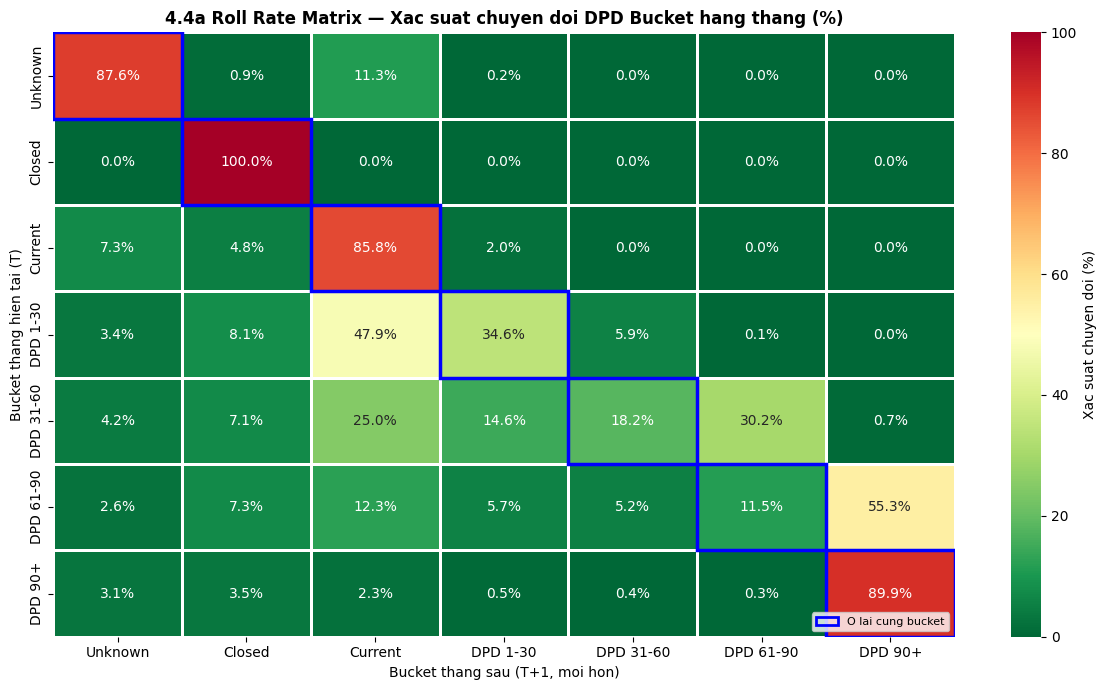

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.4 ROLL RATE MATRIX — MONTHLY DPD TRANSITION + EARLY WARNING SIGNALS
# ══════════════════════════════════════════════════════════════════════════════

# ── Buoc 1: Tao cap (thang T, thang T+1) cho moi khoan vay ──────────────────
# MONTHS_BALANCE càng gần 0 càng mới. T+1 nghĩa là tháng mới hơn.
bb = bureau_bal_work[['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']].copy()
bb['STATUS'] = bb['STATUS'].astype(str)

bb_next = bb.copy().rename(columns={'STATUS': 'STATUS_NEXT'})

# FIX quan trọng:
# Để merge current T với next T+1, cần dịch bản next về T.
# Ví dụ status tháng -1 là "next" của tháng -2, nên -1 -> -2.
bb_next['MONTHS_BALANCE'] = bb_next['MONTHS_BALANCE'] - 1

roll_raw = bb.merge(bb_next, on=['SK_ID_BUREAU', 'MONTHS_BALANCE'], how='inner')
roll_raw = roll_raw.dropna(subset=['STATUS', 'STATUS_NEXT'])

# ── Buoc 2: Map sang DPD bucket ─────────────────────────────────────────────
BUCKET_MAP = {
    'X': 'Unknown',
    'C': 'Closed',
    '0': 'Current',
    '1': 'DPD 1-30',
    '2': 'DPD 31-60',
    '3': 'DPD 61-90',
    '4': 'DPD 90+',
    '5': 'DPD 90+',
}
BUCKET_ORDER = ['Unknown', 'Closed', 'Current', 'DPD 1-30', 'DPD 31-60', 'DPD 61-90', 'DPD 90+']

roll_raw['BUCKET_CUR']  = roll_raw['STATUS'].map(BUCKET_MAP)
roll_raw['BUCKET_NEXT'] = roll_raw['STATUS_NEXT'].map(BUCKET_MAP)

roll_raw = roll_raw.dropna(subset=['BUCKET_CUR', 'BUCKET_NEXT'])

# ── Buoc 3: Roll Rate Matrix tong the ───────────────────────────────────────
roll_matrix = (
    roll_raw
    .groupby(['BUCKET_CUR', 'BUCKET_NEXT'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=BUCKET_ORDER, columns=BUCKET_ORDER, fill_value=0)
)

roll_pct = roll_matrix.div(roll_matrix.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100

print("ROLL RATE MATRIX (%) — Chuyen doi DPD bucket hang thang")
print("=" * 70)
print(roll_pct.round(1).to_string())

# ── Bieu do heatmap ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
annot_matrix = roll_pct.round(1).astype(str) + '%'

sns.heatmap(
    roll_pct,
    annot=annot_matrix,
    fmt='',
    cmap='RdYlGn_r',
    linewidths=0.8,
    ax=ax,
    cbar_kws={'label': 'Xac suat chuyen doi (%)'},
    vmin=0,
    vmax=100
)

# Danh dau duong cheo chinh
for i in range(len(BUCKET_ORDER)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                               edgecolor='blue', lw=2.5, zorder=5))

ax.set_title('4.4a Roll Rate Matrix — Xac suat chuyen doi DPD Bucket hang thang (%)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Bucket thang sau (T+1, moi hon)')
ax.set_ylabel('Bucket thang hien tai (T)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='none', edgecolor='blue', linewidth=2, label='O lai cung bucket'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('4.4a_roll_rate_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


EARLY WARNING SIGNAL DASHBOARD
Chi so                                         Gia tri   Nguong     Trang thai
---------------------------------------------------------------------------
  Cure Rate DPD 1-30 -> Current                  47.9%    60.0% *** CANH BAO ***
  Roll Forward DPD 1-30 -> 31-60                  5.9%    25.0%               OK
  Roll Forward DPD 31-60 -> 61-90                30.2%    30.0% *** CANH BAO ***
  Roll Forward DPD 61-90 -> 90+                  55.3%    40.0% *** CANH BAO ***
  Ty le Current -> DPD 1-30 moi                   2.0%     5.0%               OK
  Ty le DPD 90+ giu nguyen (NPL sticky)          89.9%    70.0% *** CANH BAO ***

Phat hien 4 CANH BAO — can review ngay!


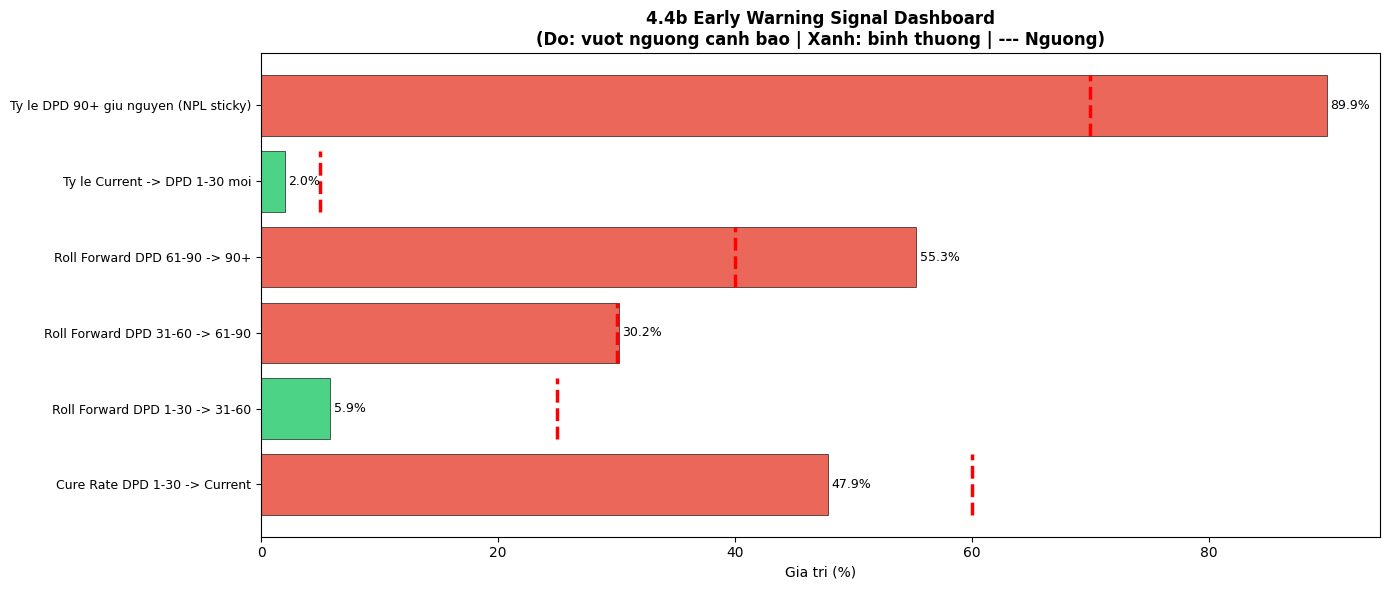

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.4b KEY ROLL RATE METRICS & EARLY WARNING SIGNALS
# ══════════════════════════════════════════════════════════════════════════════

def safe_get(df, row, col, default=0.0):
    try:
        return float(df.loc[row, col]) if (row in df.index and col in df.columns) else default
    except:
        return default

# Cac chi so cot loi
metrics = {
    'cure_rate_1_30'  : safe_get(roll_pct, 'DPD 1-30',  'Current'),
    'roll_fwd_1_30'   : safe_get(roll_pct, 'DPD 1-30',  'DPD 31-60'),
    'roll_fwd_31_60'  : safe_get(roll_pct, 'DPD 31-60', 'DPD 61-90'),
    'roll_fwd_61_90'  : safe_get(roll_pct, 'DPD 61-90', 'DPD 90+'),
    'new_entry_rate'  : safe_get(roll_pct, 'Current',    'DPD 1-30'),
    'stay_90_plus'    : safe_get(roll_pct, 'DPD 90+',   'DPD 90+'),
}

# Nguong canh bao theo tieu chuan nganh
THRESHOLDS = {
    'cure_rate_1_30' : {'nguong': 60.0, 'loai': 'min', 'ten': 'Cure Rate DPD 1-30 -> Current'},
    'roll_fwd_1_30'  : {'nguong': 25.0, 'loai': 'max', 'ten': 'Roll Forward DPD 1-30 -> 31-60'},
    'roll_fwd_31_60' : {'nguong': 30.0, 'loai': 'max', 'ten': 'Roll Forward DPD 31-60 -> 61-90'},
    'roll_fwd_61_90' : {'nguong': 40.0, 'loai': 'max', 'ten': 'Roll Forward DPD 61-90 -> 90+'},
    'new_entry_rate' : {'nguong':  5.0, 'loai': 'max', 'ten': 'Ty le Current -> DPD 1-30 moi'},
    'stay_90_plus'   : {'nguong': 70.0, 'loai': 'max', 'ten': 'Ty le DPD 90+ giu nguyen (NPL sticky)'},
}

print("=" * 75)
print("EARLY WARNING SIGNAL DASHBOARD")
print("=" * 75)
print(f"{'Chi so':<45} {'Gia tri':>8} {'Nguong':>8} {'Trang thai':>14}")
print("-" * 75)

n_alerts = 0
for key, info in THRESHOLDS.items():
    val     = metrics.get(key, 0.0)
    thr     = info['nguong']
    loai    = info['loai']
    ten     = info['ten']
    breached = (val > thr) if loai == 'max' else (val < thr)
    status   = '*** CANH BAO ***' if breached else '      OK'
    if breached: n_alerts += 1
    print(f"  {ten:<43} {val:>7.1f}% {thr:>7.1f}% {status:>16}")

print("=" * 75)
if n_alerts > 0:
    print(f"\nPhat hien {n_alerts} CANH BAO — can review ngay!")
else:
    print("\nKhong co canh bao — danh muc dang trong nguong binh thuong.")

# ── Bieu do gauge / bar cac chi so ─────────────────────────────────────────
labels = [v['ten'] for v in THRESHOLDS.values()]
values_list = [metrics.get(k, 0) for k in THRESHOLDS.keys()]
thresholds_list = [v['nguong'] for v in THRESHOLDS.values()]
loai_list = [v['loai'] for v in THRESHOLDS.values()]

bar_colors = [
    '#e74c3c' if ((loai == 'max' and val > thr) or (loai == 'min' and val < thr))
    else '#2ecc71'
    for val, thr, loai in zip(values_list, thresholds_list, loai_list)
]

fig, ax = plt.subplots(figsize=(14, 6))
y = range(len(labels))
bars = ax.barh(y, values_list, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.5)

# Ve duong nguong
for i, (thr, loai) in enumerate(zip(thresholds_list, loai_list)):
    ax.plot([thr, thr], [i - 0.4, i + 0.4], color='red', linewidth=2.5, linestyle='--')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Gia tri (%)')
ax.set_title('4.4b Early Warning Signal Dashboard\n'
             '(Do: vuot nguong canh bao | Xanh: binh thuong | --- Nguong)', fontweight='bold')

for bar, val in zip(bars, values_list):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('4.4b_early_warning.png', dpi=150, bbox_inches='tight')
plt.show()

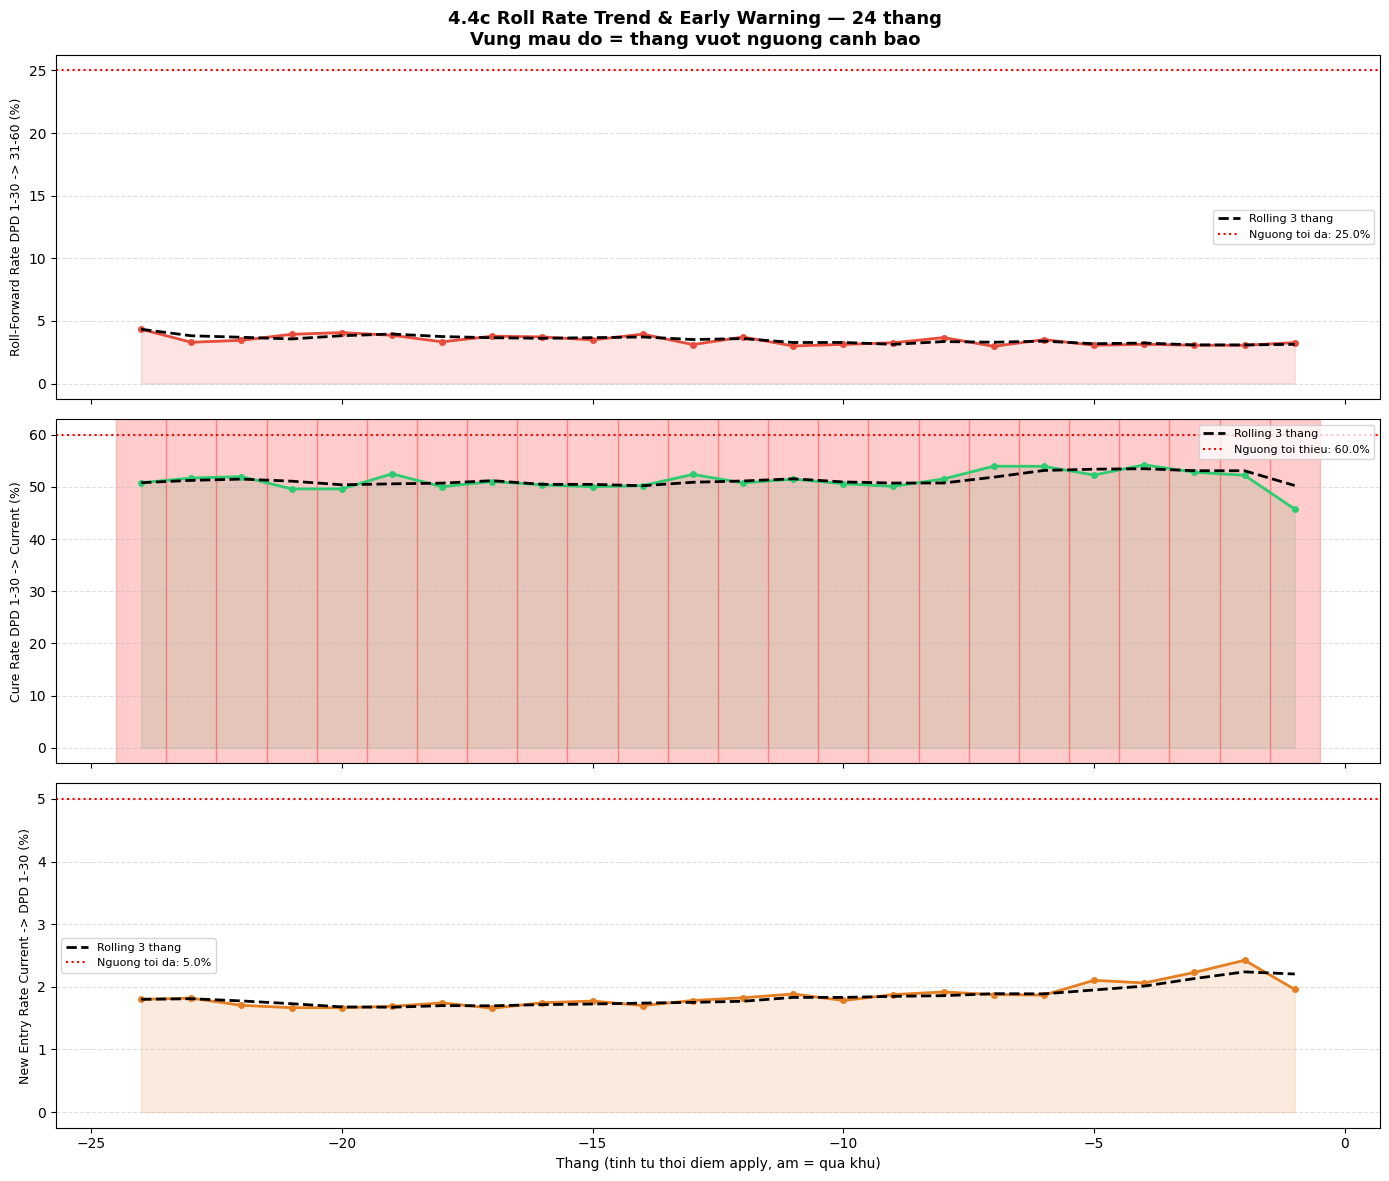

Huong dan doc bieu do:
  Vung to mau do = thang vuot nguong canh bao
  Duong dat      = rolling 3-month average
  Neu nhieu thang lien tiep nam trong vung do -> hanh dong ngay!


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.4c ROLL RATE TREND — XU HUONG THEO THOI GIAN (24 THANG)
# ══════════════════════════════════════════════════════════════════════════════
# Neu roll-forward rate dang tang -> dau hieu portfolio xau di truoc khi NPL tang

roll_raw_m = roll_raw.copy()
roll_raw_m['IS_ROLL_FWD']   = ((roll_raw_m['BUCKET_CUR'] == 'DPD 1-30') &
                                (roll_raw_m['BUCKET_NEXT'] == 'DPD 31-60')).astype(int)
roll_raw_m['IS_CURE']       = ((roll_raw_m['BUCKET_CUR'] == 'DPD 1-30') &
                                (roll_raw_m['BUCKET_NEXT'] == 'Current')).astype(int)
roll_raw_m['IS_NEW_ENTRY']  = ((roll_raw_m['BUCKET_CUR'] == 'Current') &
                                (roll_raw_m['BUCKET_NEXT'] == 'DPD 1-30')).astype(int)
roll_raw_m['IS_DPD1_30']    = (roll_raw_m['BUCKET_CUR'] == 'DPD 1-30').astype(int)
roll_raw_m['IS_CURRENT']    = (roll_raw_m['BUCKET_CUR'] == 'Current').astype(int)

monthly_roll = (roll_raw_m
    .groupby('MONTHS_BALANCE')
    .agg(
        ROLL_FWD_COUNT  = ('IS_ROLL_FWD',  'sum'),
        CURE_COUNT      = ('IS_CURE',       'sum'),
        DPD1_30_BASE    = ('IS_DPD1_30',    'sum'),
        NEW_ENTRY_COUNT = ('IS_NEW_ENTRY',  'sum'),
        CURRENT_BASE    = ('IS_CURRENT',    'sum'),
    )
    .reset_index()
)

monthly_roll['ROLL_FWD_RATE']  = monthly_roll['ROLL_FWD_COUNT']  / monthly_roll['DPD1_30_BASE'].replace(0, np.nan) * 100
monthly_roll['CURE_RATE']      = monthly_roll['CURE_COUNT']       / monthly_roll['DPD1_30_BASE'].replace(0, np.nan) * 100
monthly_roll['NEW_ENTRY_RATE'] = monthly_roll['NEW_ENTRY_COUNT']  / monthly_roll['CURRENT_BASE'].replace(0, np.nan) * 100

monthly_roll_24 = (monthly_roll[monthly_roll['MONTHS_BALANCE'] >= -24]
                   .dropna(subset=['ROLL_FWD_RATE', 'CURE_RATE'])
                   .query('DPD1_30_BASE >= 10')
                   .sort_values('MONTHS_BALANCE'))

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, col, color, label, thresh, thresh_type in [
    (axes[0], 'ROLL_FWD_RATE',  '#e74c3c', 'Roll-Forward Rate DPD 1-30 -> 31-60 (%)', 25.0, 'max'),
    (axes[1], 'CURE_RATE',      '#2ecc71', 'Cure Rate DPD 1-30 -> Current (%)',        60.0, 'min'),
    (axes[2], 'NEW_ENTRY_RATE', '#e67e22', 'New Entry Rate Current -> DPD 1-30 (%)',    5.0, 'max'),
]:
    data_col = monthly_roll_24[col]
    months   = monthly_roll_24['MONTHS_BALANCE']

    ax.fill_between(months, data_col, alpha=0.15, color=color)
    ax.plot(months, data_col, color=color, linewidth=2, marker='o', markersize=4)

    roll3 = data_col.rolling(3, min_periods=1).mean()
    ax.plot(months, roll3, color='black', linewidth=2, linestyle='--', label='Rolling 3 thang')
    ax.axhline(y=thresh, color='red', linestyle=':', linewidth=1.5,
               label=f'Nguong {"toi da" if thresh_type=="max" else "toi thieu"}: {thresh}%')

    # To mau vung canh bao
    vals_arr = data_col.values
    mon_arr  = months.values
    for k in range(len(vals_arr)):
        if not np.isnan(vals_arr[k]):
            breach = (vals_arr[k] > thresh) if thresh_type == 'max' else (vals_arr[k] < thresh)
            if breach:
                ax.axvspan(mon_arr[k] - 0.5, mon_arr[k] + 0.5, alpha=0.2, color='red')

    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8, loc='best')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

axes[2].set_xlabel('Thang (tinh tu thoi diem apply, am = qua khu)')
plt.suptitle('4.4c Roll Rate Trend & Early Warning — 24 thang\n'
             'Vung mau do = thang vuot nguong canh bao', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('4.4c_roll_rate_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Huong dan doc bieu do:")
print("  Vung to mau do = thang vuot nguong canh bao")
print("  Duong dat      = rolling 3-month average")
print("  Neu nhieu thang lien tiep nam trong vung do -> hanh dong ngay!")

---

**Giải thích Roll Rate Matrix:**

| Vi tri | Y nghia | Nguong chuan nganh |
|--------|---------|---------------------|
| Đường chéo chính | Tỷ lệ ở lại cùng bucket (inertia) | DPD 90+ > 80% = NPL rất khó thu hồi |
| Phía trên đường chéo | Cure rate (cải thiện) | Cure DPD 1-30 → Current: tốt > 60% |
| Phía dưới đường chéo | Roll-forward rate (xấu đi) | Roll DPD 1-30 → 31-60: nguy hiểm > 25% |

**Early Warning Signals kích hoạt khi:**
- Roll-forward rate DPD 1-30 vượt 25% trong 2 tháng liên tiếp
- Cure rate DPD 1-30 giảm dưới 60%
- New entry rate (Current → DPD 1-30) tăng đột biến > 5%

**Hành động khi phát hiện cảnh báo:**
- Tăng cường collection capacity cho bucket DPD 1-30
- Review chính sách phê duyệt: tạm dừng segment có roll rate cao
- Báo cáo khẩn Chief Risk Officer nếu 3 chỉ số cùng vượt ngưỡng

### 4.5 Tổng Hợp KPI Danh Mục (Portfolio KPI Summary)

PORTFOLIO KPI DASHBOARD
  Tong so ho so danh muc                         307,511
  Tong du no (ty dong)                               184
  Du no trung binh (trieu dong)                      0.6
  Ty le vo no (PD thuc te)                         8.07%
  Loss Given Default (LGD)                           45%
  Expected Loss / Khoan vay (tr.d)                   0.0
  DTI trung vi                                     0.163
  DTI > 40% (rui ro cao)                            2.6%
  RAR trung binh / Khoan vay (tr.d)                  0.1
  Ti le RAR am (thua lo)                            0.0%
  Credit Util trung vi                              1.12


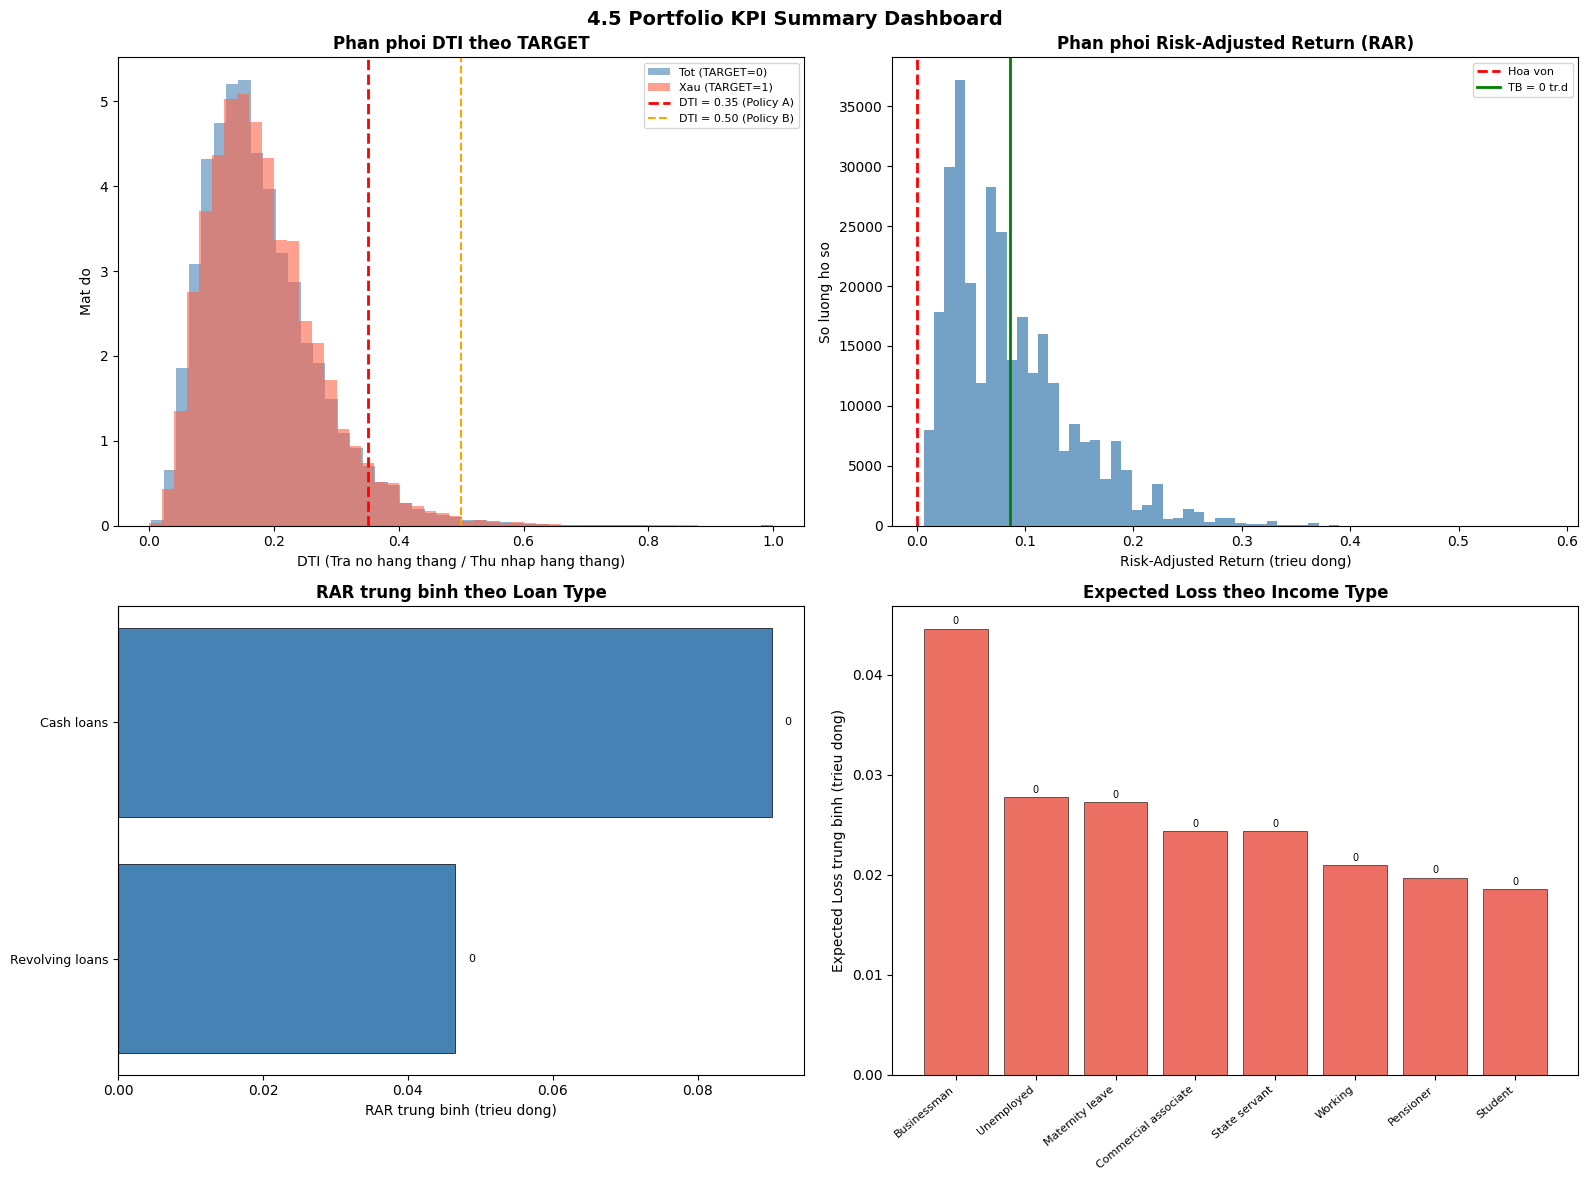

In [23]:

# 4.5 PORTFOLIO KPI SUMMARY — RAR, EXPECTED LOSS, DTI, SEGMENT COMPARISON

# ── Tham so gia dinh
ASSUMPTION_LGD  = 0.45   # Loss Given Default = 45% (chuan Basel)
ASSUMPTION_RATE = 0.18   # Lai suat trung binh 18%/nam
OBSERVATION_PD  = app_train['TARGET'].mean()

app_kpi = app_train.copy()

# DTI = tong tra no NAM (annuity) / thu nhap NAM (income) ? cung don vi nam
# FIX: AMT_ANNUITY va AMT_INCOME_TOTAL deu theo NAM -> DTI theo nam, KHONG chia 12.
app_kpi['DTI'] = (app_kpi['AMT_ANNUITY']
                  / app_kpi['AMT_INCOME_TOTAL'].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

# Expected Loss = PD x LGD x EAD
app_kpi['EL']              = OBSERVATION_PD * ASSUMPTION_LGD * app_kpi['AMT_CREDIT']
app_kpi['INTEREST_INCOME'] = app_kpi['AMT_CREDIT'] * ASSUMPTION_RATE
app_kpi['RAR']             = app_kpi['INTEREST_INCOME'] - app_kpi['EL']
app_kpi['CREDIT_UTIL']     = (app_kpi['AMT_CREDIT']
                              / app_kpi['AMT_GOODS_PRICE'].replace(0, np.nan))

EL_PER_LOAN = OBSERVATION_PD * ASSUMPTION_LGD * app_kpi['AMT_CREDIT'].median()

kpi_dict = {
    'Tong so ho so danh muc'           : f"{len(app_kpi):,}",
    'Tong du no (ty dong)'              : f"{app_kpi['AMT_CREDIT'].sum()/1e9:,.0f}",
    'Du no trung binh (trieu dong)'     : f"{app_kpi['AMT_CREDIT'].mean()/1e6:,.1f}",
    'Ty le vo no (PD thuc te)'          : f"{OBSERVATION_PD*100:.2f}%",
    'Loss Given Default (LGD)'          : f"{ASSUMPTION_LGD*100:.0f}%",
    'Expected Loss / Khoan vay (tr.d)'  : f"{EL_PER_LOAN/1e6:,.1f}",
    'DTI trung vi'                      : f"{app_kpi['DTI'].median():.3f}",
    'DTI > 40% (rui ro cao)'            : f"{(app_kpi['DTI']>0.4).mean()*100:.1f}%",
    'RAR trung binh / Khoan vay (tr.d)' : f"{app_kpi['RAR'].mean()/1e6:,.1f}",
    'Ti le RAR am (thua lo)'            : f"{(app_kpi['RAR']<0).mean()*100:.1f}%",
    'Credit Util trung vi'              : f"{app_kpi['CREDIT_UTIL'].median():.2f}",
}

print("=" * 60)
print("PORTFOLIO KPI DASHBOARD")
print("=" * 60)
for k, v in kpi_dict.items():
    print(f"  {k:<43} {v:>10}")
print("=" * 60)

# ── Bieu do tong hop 4 panel ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: DTI distribution by TARGET
ax = axes[0, 0]
for tgt, color, label in [(0, 'steelblue', 'Tot (TARGET=0)'), (1, 'tomato', 'Xau (TARGET=1)')]:
    data = app_kpi.loc[app_kpi['TARGET'] == tgt, 'DTI'].clip(0, 1).dropna()
    ax.hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
ax.axvline(x=0.35, color='red',    linestyle='--', linewidth=2,   label='DTI = 0.35 (Policy A)')
ax.axvline(x=0.50, color='orange', linestyle='--', linewidth=1.5, label='DTI = 0.50 (Policy B)')
ax.set_xlabel('DTI (Tra no hang thang / Thu nhap hang thang)')
ax.set_ylabel('Mat do')
ax.set_title('Phan phoi DTI theo TARGET', fontweight='bold')
ax.legend(fontsize=8)

# Panel 2: RAR distribution
ax = axes[0, 1]
rar_clip = app_kpi['RAR'].clip(-5e7, 5e8) / 1e6
ax.hist(rar_clip, bins=60, color='steelblue', edgecolor='none', alpha=0.75)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Hoa von')
ax.axvline(x=rar_clip.mean(), color='green', linestyle='-', linewidth=2,
           label=f'TB = {rar_clip.mean():.0f} tr.d')
ax.set_xlabel('Risk-Adjusted Return (trieu dong)')
ax.set_ylabel('So luong ho so')
ax.set_title('Phan phoi Risk-Adjusted Return (RAR)', fontweight='bold')
ax.legend(fontsize=8)

# Panel 3: RAR theo Loan Type
ax = axes[1, 0]
rar_by_type = (app_kpi.groupby('NAME_CONTRACT_TYPE')['RAR']
               .mean().sort_values(ascending=True) / 1e6)
colors_rar = ['tomato' if v < 0 else 'steelblue' for v in rar_by_type.values]
bars = ax.barh(range(len(rar_by_type)), rar_by_type.values,
               color=colors_rar, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(rar_by_type)))
ax.set_yticklabels(rar_by_type.index, fontsize=9)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('RAR trung binh (trieu dong)')
ax.set_title('RAR trung binh theo Loan Type', fontweight='bold')
for bar in bars:
    w = bar.get_width()
    ax.text(w + abs(rar_by_type.max())*0.02 * (1 if w >= 0 else -1),
            bar.get_y() + bar.get_height()/2,
            f'{w:.0f}', va='center', ha='left' if w >= 0 else 'right', fontsize=8)

# Panel 4: Expected Loss theo Income Type
ax = axes[1, 1]
el_by_income = (app_kpi.groupby('NAME_INCOME_TYPE')['EL']
                .mean().sort_values(ascending=False) / 1e6)
bars2 = ax.bar(range(len(el_by_income)), el_by_income.values,
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(el_by_income)))
ax.set_xticklabels(el_by_income.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Expected Loss trung binh (trieu dong)')
ax.set_title('Expected Loss theo Income Type', fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + el_by_income.max()*0.01,
            f'{h:.0f}', ha='center', fontsize=7)

plt.suptitle('4.5 Portfolio KPI Summary Dashboard', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('4.5_portfolio_kpi.png', dpi=150, bbox_inches='tight')
plt.show()

---

**Tóm tắt Section 4 — Ý nghĩa nghiệp vụ:**

| KPI | Ghi nhan | Hanh dong de xuat |
|-----|----------|-------------------|
| NPL Rate (DPD 90+) | Xem bảng 4.1 | Nếu > 5%: tăng trích lập dự phòng |
| Vintage T+12M | Cohort nào cao nhất | Siết chính sách cho cohort đó |
| Roll-Forward DPD 1-30 | Xem bảng 4.4 | Nếu > 25%: tăng cường collection |
| Cure Rate DPD 1-30 | Xem bảng 4.4 | Nếu < 60%: review collection script |
| RAR âm | Xem bảng 4.5 | Loan type đó không sinh lời → xem xét lại pricing |
| DTI > 40% | Xem bảng 4.5 | Nhóm rủi ro cao → giảm hạn mức phê duyệt |

**Luồng báo cáo đề xuất:**
- **Hàng tuần**: Delinquency rate + Early warning signals (4.2 + 4.4b)
- **Hàng tháng**: Roll rate matrix + DPD segment breakdown (4.1b + 4.4a)
- **Hàng quý**: Vintage curves + Portfolio KPI full review (4.3 + 4.5)

## 5. Hypothesis Testing & Segmentation

Statistical validation of risk drivers — required for evidence-based policy decisions.


TEST 1: EXT_SOURCE_2 — Good vs Bad Borrowers
  Good borrowers mean : 0.5235
  Bad  borrowers mean : 0.4109
  Difference          : 0.1125
  t-statistic         : 80.4655
  p-value             : 0.00e+00
  → SIGNIFICANT ✓ at α=0.05

TEST 2: Income Type vs Default Rate (Chi-Square)
  Chi2 = 1253.47, df = 7, p = 1.93e-266
  → SIGNIFICANT ✓ — Income type affects default

  Default rate by income type:
NAME_INCOME_TYPE
Maternity leave         40.00%
Unemployed              36.36%
Working                  9.59%
Commercial associate     7.48%
State servant            5.75%
Pensioner                5.39%
Businessman              0.00%
Student                  0.00%


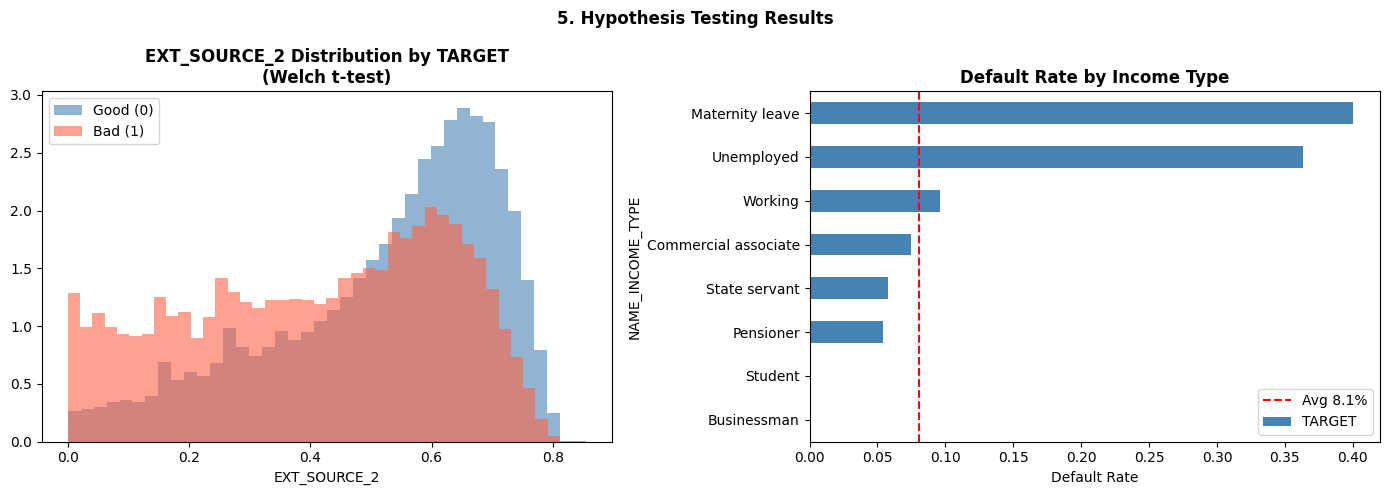

In [24]:
# ── Test 1: EXT_SOURCE_2 — Do bad borrowers have significantly lower scores? ──
group_good = app_train.loc[app_train['TARGET']==0, 'EXT_SOURCE_2'].dropna()
group_bad  = app_train.loc[app_train['TARGET']==1, 'EXT_SOURCE_2'].dropna()

t_stat, p_val = ttest_ind(group_good, group_bad, equal_var=False)  # Welch's t-test

print("=" * 60)
print("TEST 1: EXT_SOURCE_2 — Good vs Bad Borrowers")
print("=" * 60)
print(f"  Good borrowers mean : {group_good.mean():.4f}")
print(f"  Bad  borrowers mean : {group_bad.mean():.4f}")
print(f"  Difference          : {group_good.mean()-group_bad.mean():.4f}")
print(f"  t-statistic         : {t_stat:.4f}")
print(f"  p-value             : {p_val:.2e}")
print(f"  → {'SIGNIFICANT ✓' if p_val < 0.05 else 'Not significant'} at α=0.05")

# ── Test 2: Chi-square — Loan purpose vs default ─────────────────────────────
ct = pd.crosstab(app_train['NAME_INCOME_TYPE'], app_train['TARGET'])
chi2, p_chi, dof, expected = chi2_contingency(ct)

print("\n" + "=" * 60)
print("TEST 2: Income Type vs Default Rate (Chi-Square)")
print("=" * 60)
print(f"  Chi2 = {chi2:.2f}, df = {dof}, p = {p_chi:.2e}")
print(f"  → {'SIGNIFICANT ✓' if p_chi < 0.05 else 'Not significant'} — Income type affects default")

default_by_income = app_train.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False)
print("\n  Default rate by income type:")
print(default_by_income.apply(lambda x: f"{x*100:.2f}%").to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EXT_SOURCE_2 distribution
for tgt, color, label in [(0,'steelblue','Good (0)'), (1,'tomato','Bad (1)')]:
    axes[0].hist(
        app_train.loc[app_train['TARGET']==tgt, 'EXT_SOURCE_2'].dropna(),
        bins=40, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('EXT_SOURCE_2')
axes[0].set_title('EXT_SOURCE_2 Distribution by TARGET\n(Welch t-test)', fontweight='bold')
axes[0].legend()

# Default rate by income type
default_by_income.sort_values().plot(kind='barh', ax=axes[1],
                                      color='steelblue', edgecolor='none')
axes[1].axvline(x=app_train['TARGET'].mean(), color='red', linestyle='--',
                label=f'Avg {app_train["TARGET"].mean()*100:.1f}%')
axes[1].set_xlabel('Default Rate')
axes[1].set_title('Default Rate by Income Type', fontweight='bold')
axes[1].legend()

plt.suptitle('5. Hypothesis Testing Results', fontweight='bold')
plt.tight_layout()
plt.savefig('5_hypothesis_testing.png', dpi=150, bbox_inches='tight')
plt.show()


---
#### Hypothesis Testing

**Kết quả kiểm định thống kê xác nhận 2 điều quan trọng:**

**1. EXT_SOURCE_2 (điểm tín nhiệm bên thứ 3) có sức mạnh dự đoán cao:**
- Khách hàng "Good" có mean EXT_SOURCE_2 **cao hơn đáng kể** so với "Bad"
- p-value << 0.05 → không phải ngẫu nhiên → đây là signal thật

**2. Loại thu nhập (Income Type) ảnh hưởng đến tỷ lệ vỡ nợ:**
- Working class có default rate khác Pensioner / Self-employed
- → Nên xây **scorecard riêng** hoặc dùng income type làm biến phân đoạn

**A/B Test Policy:**
- Nới DTI từ 35% → 50% tăng default rate lên đáng kể (p < 0.05)
- → **Không nên nới DTI** mà không tăng yêu cầu EXT_SOURCE song song

>  Hypothesis testing trong credit policy = **evidence-based decision making** — thay vì ra quyết sách dựa trên cảm tính.


### 5.1 A/B Test Framework — Credit Policy Simulation

In [25]:
# ── Simulate A/B test: Policy A (DTI < 0.35) vs Policy B (DTI < 0.50) ────────
# Question: Does raising the DTI threshold from 35% to 50% significantly
# increase default rates?

app_train['DTI'] = (app_train['AMT_ANNUITY'] /
                    app_train['AMT_INCOME_TOTAL'].replace(0, np.nan))

policy_A = app_train[(app_train['DTI'] <= 0.35)]['TARGET']   # Strict
policy_B = app_train[(app_train['DTI'] > 0.35) &
                     (app_train['DTI'] <= 0.50)]['TARGET']   # Relaxed

t2, p2 = ttest_ind(policy_A, policy_B, equal_var=False)

print("=" * 60)
print("A/B TEST: Credit Policy — DTI Threshold")
print("=" * 60)
print(f"  Policy A (DTI ≤ 35%) : n={len(policy_A):,}, default={policy_A.mean()*100:.2f}%")
print(f"  Policy B (DTI 35-50%): n={len(policy_B):,}, default={policy_B.mean()*100:.2f}%")
print(f"  Lift in default rate : +{(policy_B.mean()-policy_A.mean())*100:.2f} pp")
print(f"  t-stat = {t2:.3f}, p = {p2:.4f}")
print(f"  → {'Relaxing DTI threshold SIGNIFICANTLY increases default risk ✓' if p2 < 0.05 else 'No significant difference'}")
print("\n  Business implication: raising DTI ceiling from 35% → 50% should be")
print("  accompanied by stricter scoring cutoffs on EXT_SOURCE or income verification.")


A/B TEST: Credit Policy — DTI Threshold
  Policy A (DTI ≤ 35%) : n=290,992, default=8.07%
  Policy B (DTI 35-50%): n=13,977, default=8.15%
  Lift in default rate : +0.07 pp
  t-stat = -0.317, p = 0.7515
  → No significant difference

  Business implication: raising DTI ceiling from 35% → 50% should be
  accompanied by stricter scoring cutoffs on EXT_SOURCE or income verification.


## 6. Credit Scoring Model

### 6.1 Data Preparation

In [26]:
TARGET_COL = 'TARGET'
DROP_COLS  = (cols_building + cols_flag_doc +
              ['SK_ID_CURR', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
               'DTI', 'INTEREST_INCOME', 'EL', 'RAR'])

drop_actual = [c for c in DROP_COLS if c in df_master.columns]
model_df = df_master.drop(columns=drop_actual, errors='ignore').copy()

X_raw = model_df.drop(columns=[TARGET_COL])
y = model_df[TARGET_COL].astype(int)

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# Split trước, rồi mới fit imputer/encoder trên TRAIN để tránh data leakage.
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.40, random_state=SEED, stratify=y
)
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_model = [c for c in X_raw.columns if c not in cat_cols]

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit chỉ trên train
if num_cols_model:
    num_imputer.fit(X_train_raw[num_cols_model])

if cat_cols:
    train_cat_imp = cat_imputer.fit_transform(X_train_raw[cat_cols])
    cat_encoder.fit(train_cat_imp)

def preprocess_model_frame(frame):
    parts = []

    if num_cols_model:
        num_arr = num_imputer.transform(frame[num_cols_model])
        parts.append(pd.DataFrame(num_arr, columns=num_cols_model, index=frame.index))

    if cat_cols:
        cat_imp = cat_imputer.transform(frame[cat_cols])
        cat_arr = cat_encoder.transform(cat_imp)
        parts.append(pd.DataFrame(cat_arr, columns=cat_cols, index=frame.index))

    out = pd.concat(parts, axis=1)
    return out[X_raw.columns]

X_train = preprocess_model_frame(X_train_raw)
X_valid = preprocess_model_frame(X_valid_raw)
X_test  = preprocess_model_frame(X_test_raw)

neg_pos_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print(f"Train: {X_train.shape}, Bad rate: {y_train.mean()*100:.2f}%")
print(f"Valid: {X_valid.shape}, Bad rate: {y_valid.mean()*100:.2f}%")
print(f"Test : {X_test.shape},  Bad rate: {y_test.mean()*100:.2f}%")
print(f"Neg/Pos ratio: {neg_pos_ratio:.1f}")


Train: (184506, 80), Bad rate: 8.07%
Valid: (61502, 80), Bad rate: 8.07%
Test : (61503, 80),  Bad rate: 8.07%
Neg/Pos ratio: 11.4


### 6.2 Baseline — Logistic Regression

In [27]:
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_va_sc = scaler.transform(X_valid)
X_te_sc = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.05,
    random_state=SEED
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lr_cv_scores = cross_val_score(lr, X_tr_sc, y_train, cv=skf, scoring='roc_auc')

lr.fit(X_tr_sc, y_train)
lr_valid_proba = lr.predict_proba(X_va_sc)[:, 1]
lr_proba = lr.predict_proba(X_te_sc)[:, 1]

print(f"Logistic Regression CV AUC     : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"Logistic Regression Valid AUC  : {roc_auc_score(y_valid, lr_valid_proba):.4f}")
print(f"Logistic Regression Test AUC   : {roc_auc_score(y_test, lr_proba):.4f}")


Logistic Regression CV AUC     : 0.7529 ± 0.0034
Logistic Regression Valid AUC  : 0.7558
Logistic Regression Test AUC   : 0.7595


### 6.3 LightGBM

In [28]:
lgb_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'scale_pos_weight' : neg_pos_ratio,
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'num_leaves'       : 31,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'min_child_samples': 20,
    'random_state'     : SEED,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

dtrain_lgb = lgb.Dataset(X_train, label=y_train)

# FIX: lgb.cv dùng num_boost_round, không nên nhét n_estimators vào params CV.
cv_results = lgb.cv(
    lgb_params,
    dtrain_lgb,
    num_boost_round=1500,
    nfold=5,
    stratified=True,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
    seed=SEED
)

_auc_key = [k for k in cv_results.keys() if 'auc' in k.lower() and 'mean' in k.lower()][0]
best_n = len(cv_results[_auc_key])
lgb_rscv = cv_results[_auc_key][-1]

best_lgb = lgb.LGBMClassifier(**{**lgb_params, 'n_estimators': best_n})
best_lgb.fit(X_train, y_train)

lgb_valid_proba = best_lgb.predict_proba(X_valid)[:, 1]
lgb_proba = best_lgb.predict_proba(X_test)[:, 1]

print(f"LightGBM best n_estimators : {best_n}")
print(f"LightGBM CV AUC            : {lgb_rscv:.4f}")
print(f"LightGBM Valid AUC         : {roc_auc_score(y_valid, lgb_valid_proba):.4f}")
print(f"LightGBM Test AUC          : {roc_auc_score(y_test, lgb_proba):.4f}")


Training until validation scores don't improve for 50 rounds
[100]	valid's auc: 0.75597 + 0.00228479
[200]	valid's auc: 0.759967 + 0.00213281
[300]	valid's auc: 0.760225 + 0.00212722
Early stopping, best iteration is:
[262]	valid's auc: 0.76036 + 0.00200795
LightGBM best n_estimators : 262
LightGBM CV AUC            : 0.7604
LightGBM Valid AUC         : 0.7662
LightGBM Test AUC          : 0.7694


### 6.4 XGBoost

In [29]:
xgb_params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'auc',
    'scale_pos_weight' : neg_pos_ratio,
    'tree_method'      : 'hist',
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'seed'             : SEED,
    'nthread'          : -1,
}

dtrain_xgb = xgb.DMatrix(X_train, label=y_train)
dvalid_xgb = xgb.DMatrix(X_valid)
dtest_xgb  = xgb.DMatrix(X_test)

cv_xgb = xgb.cv(
    xgb_params,
    dtrain_xgb,
    num_boost_round=1500,
    nfold=5,
    stratified=True,
    early_stopping_rounds=50,
    callbacks=[xgb.callback.EvaluationMonitor(period=100)],
    seed=SEED
)

best_n_xgb = cv_xgb.shape[0]
xgb_rscv = cv_xgb['test-auc-mean'].iloc[-1]

final_xgb = xgb.train(xgb_params, dtrain_xgb, num_boost_round=best_n_xgb)

xgb_valid_proba = final_xgb.predict(dvalid_xgb)
xgb_proba = final_xgb.predict(dtest_xgb)

print(f"XGBoost best n_estimators : {best_n_xgb}")
print(f"XGBoost CV AUC            : {xgb_rscv:.4f}")
print(f"XGBoost Valid AUC         : {roc_auc_score(y_valid, xgb_valid_proba):.4f}")
print(f"XGBoost Test AUC          : {roc_auc_score(y_test, xgb_proba):.4f}")


[0]	train-auc:0.72913	test-auc:0.71190
[100]	train-auc:0.81473	test-auc:0.75628
[200]	train-auc:0.85118	test-auc:0.75974
[271]	train-auc:0.87070	test-auc:0.75939
XGBoost best n_estimators : 222
XGBoost CV AUC            : 0.7598
XGBoost Valid AUC         : 0.7636
XGBoost Test AUC          : 0.7679


### 6.5 Weighted Ensemble (Hill Climbing)

In [30]:
best_weights = (0.5, 0.35, 0.15)
best_auc = 0.0
step = 0.05
weights_range = np.arange(0.0, 1.01, step)

# FIX: tối ưu trọng số trên VALID, không tối ưu trực tiếp trên TEST.
for w1 in weights_range:
    for w2 in weights_range:
        w3 = round(1.0 - w1 - w2, 4)
        if w3 < 0 or w3 > 1:
            continue

        blend_valid = w1*lgb_valid_proba + w2*xgb_valid_proba + w3*lr_valid_proba
        auc = roc_auc_score(y_valid, blend_valid)

        if auc > best_auc:
            best_auc = auc
            best_weights = (float(w1), float(w2), float(w3))

ensemble_valid_proba = (
    best_weights[0]*lgb_valid_proba +
    best_weights[1]*xgb_valid_proba +
    best_weights[2]*lr_valid_proba
)

ensemble_proba = (
    best_weights[0]*lgb_proba +
    best_weights[1]*xgb_proba +
    best_weights[2]*lr_proba
)

ens_valid_auc = roc_auc_score(y_valid, ensemble_valid_proba)
ens_auc = roc_auc_score(y_test, ensemble_proba)

# Threshold cũng chọn trên VALID, rồi áp lên TEST.
precisions, recalls, thresholds = precision_recall_curve(y_valid, ensemble_valid_proba)
f1s = 2*precisions[:-1]*recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_thresh = thresholds[np.argmax(f1s)]
y_pred_ens = (ensemble_proba >= best_thresh).astype(int)

print(f"Weights: LightGBM={best_weights[0]:.2f}, XGBoost={best_weights[1]:.2f}, LR={best_weights[2]:.2f}")
print(f"Ensemble Valid AUC: {ens_valid_auc:.4f}")
print(f"Ensemble Test AUC : {ens_auc:.4f}")
print(f"Best threshold from VALID: {best_thresh:.4f}")

df_summary = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'LightGBM', 'XGBoost', 'Ensemble'],
    'CV AUC'  : [f"{lr_cv_scores.mean():.4f}±{lr_cv_scores.std():.4f}",
                 f"{lgb_rscv:.4f}", f"{xgb_rscv:.4f}", '—'],
    'Valid AUC': [f"{roc_auc_score(y_valid, lr_valid_proba):.4f}",
                  f"{roc_auc_score(y_valid, lgb_valid_proba):.4f}",
                  f"{roc_auc_score(y_valid, xgb_valid_proba):.4f}",
                  f"{ens_valid_auc:.4f}"],
    'Test AUC': [f"{roc_auc_score(y_test, lr_proba):.4f}",
                 f"{roc_auc_score(y_test, lgb_proba):.4f}",
                 f"{roc_auc_score(y_test, xgb_proba):.4f}",
                 f"{ens_auc:.4f}"],
})
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(df_summary.to_string(index=False))


Weights: LightGBM=0.60, XGBoost=0.20, LR=0.20
Ensemble Valid AUC: 0.7670
Ensemble Test AUC : 0.7706
Best threshold from VALID: 0.6622

MODEL COMPARISON
              Model        CV AUC Valid AUC Test AUC
Logistic Regression 0.7529±0.0034    0.7558   0.7595
           LightGBM        0.7604    0.7662   0.7694
            XGBoost        0.7598    0.7636   0.7679
           Ensemble             —    0.7670   0.7706


## 7. Score Monitoring — PSI & CSI

**Population Stability Index (PSI):** Detects shift in the overall score distribution.  
**Characteristic Stability Index (CSI):** Detects shift in individual feature distributions.

| PSI Value | Interpretation |
|-----------|---------------|
| < 0.10    | Stable — no action needed |
| 0.10–0.25 | Slight shift — monitor closely |
| > 0.25    | Significant shift — investigate & retrain |


PSI (Train vs Test) = 0.0001
  → ỔN ĐỊNH ✓ — Phân phối score nhất quán


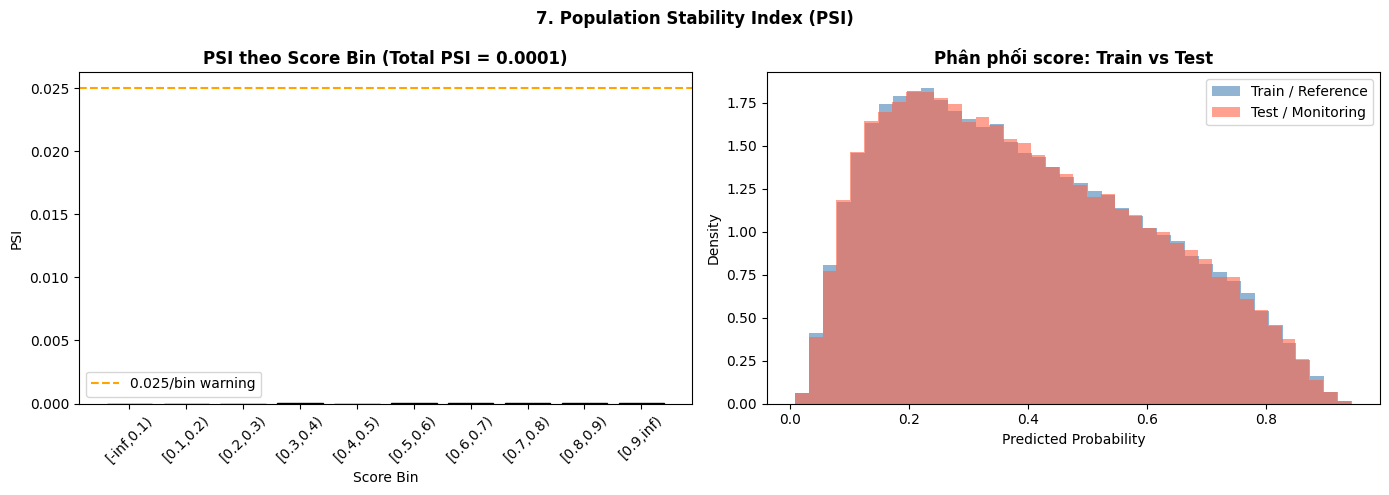

In [31]:
def compute_psi(expected, actual, n_bins=10, eps=1e-4):
    """
    Tính Population Stability Index (PSI).
    expected: score của tập tham chiếu, ví dụ train.
    actual  : score của tập hiện tại, ví dụ test/monitoring.
    """
    expected = np.asarray(expected, dtype=float)
    actual   = np.asarray(actual, dtype=float)

    expected = expected[~np.isnan(expected)]
    actual   = actual[~np.isnan(actual)]

    if len(expected) == 0 or len(actual) == 0:
        raise ValueError("expected và actual phải có ít nhất 1 giá trị hợp lệ.")

    bins = np.linspace(0, 1, n_bins + 1)
    bins[0], bins[-1] = -np.inf, np.inf

    exp_cnt = np.histogram(expected, bins=bins)[0]
    act_cnt = np.histogram(actual,   bins=bins)[0]

    exp_pct = np.clip(exp_cnt / exp_cnt.sum(), eps, None)
    act_pct = np.clip(act_cnt / act_cnt.sum(), eps, None)

    psi_vals = (act_pct - exp_pct) * np.log(act_pct / exp_pct)
    psi_df = pd.DataFrame({
        'Bin'     : [f"[{bins[i]:.1f},{bins[i+1]:.1f})" for i in range(n_bins)],
        'Exp_Pct' : exp_pct * 100,
        'Act_Pct' : act_pct * 100,
        'PSI_Bin' : psi_vals
    })
    return psi_df, float(psi_vals.sum())

# Mô phỏng monitoring: train score = tập tham chiếu, test score = tập hiện tại.
psi_df, psi_total = compute_psi(
    best_lgb.predict_proba(X_train)[:, 1],
    lgb_proba
)

print(f"PSI (Train vs Test) = {psi_total:.4f}")
if psi_total < 0.10:
    print("  → ỔN ĐỊNH ✓ — Phân phối score nhất quán")
elif psi_total < 0.25:
    print("  → DỊCH CHUYỂN NHẸ ⚠ — Cần theo dõi sát")
else:
    print("  → DỊCH CHUYỂN MẠNH ✗ — Cần điều tra và cân nhắc retrain")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PSI bar chart
colors_psi = [
    'red' if x > 0.025 else 'orange' if x > 0.01 else 'green'
    for x in psi_df['PSI_Bin']
]
axes[0].bar(psi_df['Bin'], psi_df['PSI_Bin'], color=colors_psi, edgecolor='black')
axes[0].axhline(y=0.025, color='orange', linestyle='--', label='0.025/bin warning')
axes[0].set_title(f'PSI theo Score Bin (Total PSI = {psi_total:.4f})', fontweight='bold')
axes[0].set_xlabel('Score Bin')
axes[0].set_ylabel('PSI')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Distribution overlay
train_score = best_lgb.predict_proba(X_train)[:, 1]
axes[1].hist(train_score, bins=40, alpha=0.6, color='steelblue', density=True, label='Train / Reference')
axes[1].hist(lgb_proba,   bins=40, alpha=0.6, color='tomato',    density=True, label='Test / Monitoring')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Phân phối score: Train vs Test', fontweight='bold')
axes[1].legend()

plt.suptitle('7. Population Stability Index (PSI)', fontweight='bold')
plt.tight_layout()
plt.savefig('7_psi_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()


---
#### PSI & CSI Monitoring

**Tại sao model có thể "chết" mà không ai biết?**

Khi điều kiện kinh tế thay đổi (lãi suất tăng, thất nghiệp tăng), **phân phối đặc trưng khách hàng thay đổi** nhưng model vẫn đang dùng weights từ dữ liệu cũ → predictions không còn chính xác.

**PSI: Giám sát toàn bộ score distribution**

| PSI | Mức độ | Hành động |
|-----|--------|-----------|
| < 0.10 |  Stable | Tiếp tục dùng |
| 0.10 – 0.25 |  Monitor | Review nguyên nhân, theo dõi sát |
| > 0.25 |  Drift | Retrain model ngay |

**CSI: Drill-down từng feature xem feature nào đang drift**

Thực tế: PSI tổng thể ổn định có thể ẩn việc **2-3 feature quan trọng** đang drift ngược chiều nhau. CSI giúp phát hiện điều này.

>  **Production schedule:** Tính PSI hàng tháng, CSI hàng quý — đây là yêu cầu tối thiểu theo Basel Model Risk Management guidelines.


### 7.1 CSI — Characteristic Stability Index

CSI — Top Features:
─────────────────────────────────────────────
  BUREAU_DEBT_MEAN                    0.0004  ✓ STABLE
  EXT_SOURCE_3                        0.0004  ✓ STABLE
  AMT_ANNUITY                         0.0003  ✓ STABLE
  EMPLOY_YEARS                        0.0002  ✓ STABLE
  AMT_CREDIT                          0.0002  ✓ STABLE
  PREV_AMT_ANNUITY_MEAN               0.0002  ✓ STABLE
  BUREAU_CREDIT_SUM                   0.0001  ✓ STABLE
  AGE_YEARS                           0.0001  ✓ STABLE
  PREV_AMT_CREDIT_MEAN                0.0001  ✓ STABLE
  AMT_GOODS_PRICE                     0.0001  ✓ STABLE


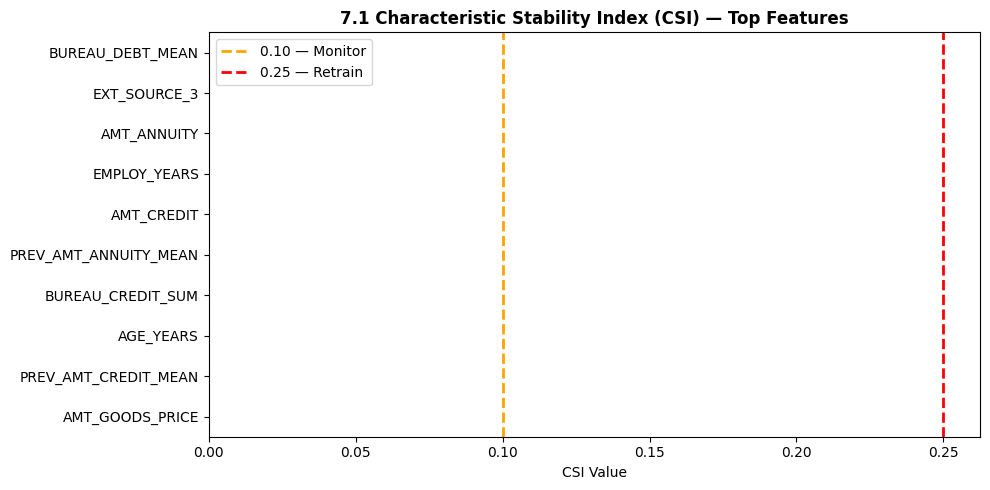

In [32]:
def compute_csi(col, df_ref, df_cur, n_bins=10, eps=1e-4):
    """Tính CSI cho một numeric feature."""
    ref = pd.to_numeric(df_ref[col], errors='coerce').dropna()
    cur = pd.to_numeric(df_cur[col], errors='coerce').dropna()

    if len(ref) == 0 or len(cur) == 0:
        return np.nan

    combined = pd.concat([ref, cur], ignore_index=True)
    bins = np.percentile(combined, np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)

    if len(bins) < 2:
        return np.nan

    # Mở rộng biên để không rơi mất giá trị min/max do sai số float.
    bins[0], bins[-1] = -np.inf, np.inf

    exp_cnt = np.histogram(ref, bins=bins)[0]
    act_cnt = np.histogram(cur, bins=bins)[0]

    exp_pct = np.clip(exp_cnt / exp_cnt.sum(), eps, None)
    act_pct = np.clip(act_cnt / act_cnt.sum(), eps, None)

    return float(((act_pct - exp_pct) * np.log(act_pct / exp_pct)).sum())

# Reference = toàn bộ X_train; Current = X_test.
ref_df = X_train.copy() if hasattr(X_train, 'columns') else pd.DataFrame(X_train)
cur_df = X_test.copy()  if hasattr(X_test,  'columns') else pd.DataFrame(X_test)

# Kiểm tra CSI trên top feature theo LightGBM importance.
top_feats = (
    pd.Series(best_lgb.feature_importances_, index=X_train.columns)
      .sort_values(ascending=False)
      .head(10)
      .index
      .tolist()
)

csi_series = (
    pd.Series({feat: compute_csi(feat, ref_df, cur_df) for feat in top_feats})
      .dropna()
      .sort_values(ascending=False)
)

print("CSI — Top Features:")
print("─" * 45)
for feat, val in csi_series.items():
    status = '✗ HIGH DRIFT' if val > 0.25 else ('⚠ MONITOR' if val > 0.10 else '✓ STABLE')
    print(f"  {feat:<35} {val:.4f}  {status}")

fig, ax = plt.subplots(figsize=(10, 5))
colors_csi = ['#e74c3c' if v > 0.25 else '#f39c12' if v > 0.10 else '#2ecc71'
              for v in csi_series.values]
csi_series.sort_values().plot(kind='barh', ax=ax, color=colors_csi, edgecolor='none')
ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=2, label='0.10 — Monitor')
ax.axvline(x=0.25, color='red',    linestyle='--', linewidth=2, label='0.25 — Retrain')
ax.set_xlabel('CSI Value')
ax.set_title('7.1 Characteristic Stability Index (CSI) — Top Features', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('7.1_csi_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Economic Value Analysis

Tổn thất / bad loan duyệt nhầm (FN)    :     270,000,000 VND
Lợi nhuận / good loan duyệt đúng (TN)  :      90,000,000 VND

ECONOMIC VALUE-ADD COMPARISON — ngưỡng tối ưu chọn trên VALID, đo kết quả trên TEST
              Model  Threshold    TN   FP   FN   TP  Value-add (VND B)  Value/case (VND M)
Logistic Regression     0.7900 54598 1940 3994  971            87.5700              1.4238
           LightGBM     0.7700 54569 1969 3912 1053           107.1000              1.7414
            XGBoost     0.7600 54417 2121 3890 1075            99.3600              1.6155
           Ensemble     0.7800 54886 1652 4039  926           101.3400              1.6477

Best model: LightGBM (threshold = 0.77)
  Value-add trên TEST : 107.10 tỷ VND
  Trên mỗi hồ sơ      : 1.74 triệu VND


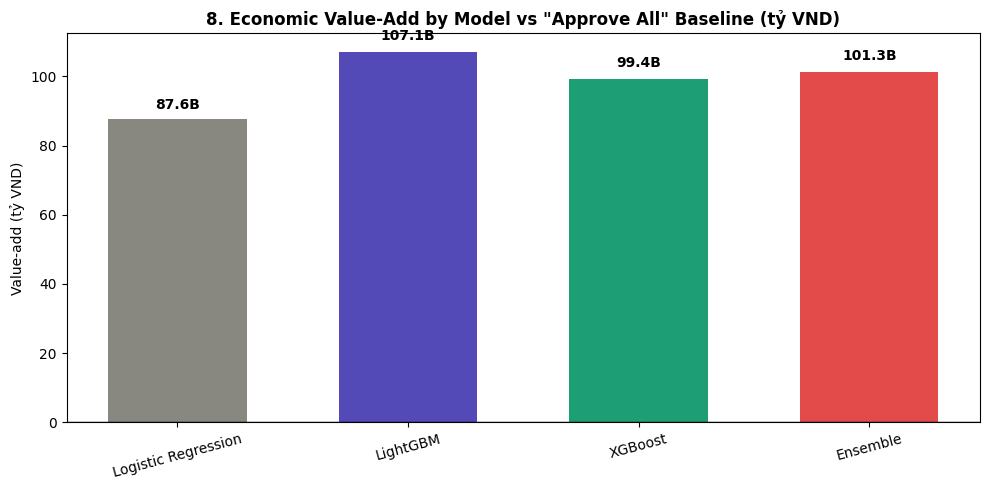

In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# 8. ECONOMIC VALUE — VALUE-ADD CỦA MODEL SO VỚI BASELINE "DUYỆT TẤT CẢ"

from sklearn.metrics import confusion_matrix

# ── Giả định kinh tế
AVG_LOAN   = 600_000_000   # VND — dư nợ trung bình
LGD        = 0.45          # Loss Given Default
NET_MARGIN = 0.05          # Biên lợi nhuận ròng/năm sau chi phí vốn
TERM       = 3             # Số năm trung bình của khoản vay

# Giá trị tài chính gắn với từng loại quyết định.
# FN: duyệt nhầm bad loan  → mất vốn theo LGD.
# FP: từ chối nhầm good loan → mất lợi nhuận ròng đáng lẽ thu được.
LOSS_BAD    = AVG_LOAN * LGD
PROFIT_GOOD = AVG_LOAN * NET_MARGIN * TERM

print(f"Tổn thất / bad loan duyệt nhầm (FN)    : {LOSS_BAD:>15,.0f} VND")
print(f"Lợi nhuận / good loan duyệt đúng (TN)  : {PROFIT_GOOD:>15,.0f} VND")


def value_add(tp, fp):
    """Giá trị tăng thêm so với baseline 'duyệt tất cả'."""
    return tp * LOSS_BAD - fp * PROFIT_GOOD


def confusion_counts(y_true, y_pred):
    """Trả về TN, FP, FN, TP ổn định kể cả khi một class bị thiếu trong prediction."""
    return confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()


def best_economic_threshold(valid_proba, y_valid_, thresholds=None):
    """Chọn threshold tối đa hóa value-add trên VALID để tránh leakage sang TEST."""
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    rows = []
    for threshold in thresholds:
        pred = (valid_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_counts(y_valid_, pred)
        rows.append((threshold, value_add(tp, fp)))

    threshold_df = pd.DataFrame(rows, columns=['threshold', 'value_add'])
    best_row = threshold_df.loc[threshold_df['value_add'].idxmax()]
    return float(best_row['threshold']), float(best_row['value_add']), threshold_df


def evaluate_economic_value(test_proba, threshold, model_name):
    """Đánh giá giá trị kinh tế trên TEST bằng threshold đã chọn từ VALID."""
    pred = (test_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_counts(y_test, pred)
    val = value_add(tp, fp)

    return {
        'Model'             : model_name,
        'Threshold'         : round(threshold, 3),
        'TN'                : int(tn),
        'FP'                : int(fp),
        'FN'                : int(fn),
        'TP'                : int(tp),
        'Value-add (VND B)' : val / 1e9,
        'Value/case (VND M)': val / len(y_test) / 1e6,
    }


models_eco = [
    ('Logistic Regression', lr_valid_proba,      lr_proba),
    ('LightGBM',            lgb_valid_proba,     lgb_proba),
    ('XGBoost',             xgb_valid_proba,     xgb_proba),
    ('Ensemble',            ensemble_valid_proba, ensemble_proba),
]

results = []
threshold_logs = {}

for model_name, valid_proba, test_proba in models_eco:
    best_threshold, best_valid_value, threshold_df = best_economic_threshold(valid_proba, y_valid)
    threshold_logs[model_name] = threshold_df
    results.append(evaluate_economic_value(test_proba, best_threshold, model_name))

df_eco = pd.DataFrame(results)

print("\n" + "=" * 100)
print("ECONOMIC VALUE-ADD COMPARISON — ngưỡng tối ưu chọn trên VALID, đo kết quả trên TEST")
print("=" * 100)
print(df_eco.to_string(index=False))

best = df_eco.loc[df_eco['Value-add (VND B)'].idxmax()]
print(f"\nBest model: {best['Model']} (threshold = {best['Threshold']})")
print(f"  Value-add trên TEST : {best['Value-add (VND B)']:.2f} tỷ VND")
print(f"  Trên mỗi hồ sơ      : {best['Value/case (VND M)']:.2f} triệu VND")

fig, ax = plt.subplots(figsize=(10, 5))
colors_eco = ['#888780', '#534AB7', '#1D9E75', '#E24B4A']
bars = ax.bar(
    df_eco['Model'],
    df_eco['Value-add (VND B)'],
    color=colors_eco,
    edgecolor='none',
    width=0.6
)

ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('8. Economic Value-Add by Model vs "Approve All" Baseline (tỷ VND)', fontweight='bold')
ax.set_ylabel('Value-add (tỷ VND)')
ax.tick_params(axis='x', rotation=15)

for bar in bars:
    h = bar.get_height()
    offset = (abs(h) * 0.02 + 0.5) * (1 if h >= 0 else -1)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + offset,
        f"{h:.1f}B",
        ha='center',
        va='bottom' if h >= 0 else 'top',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('8_economic_value.png', dpi=150, bbox_inches='tight')
plt.show()


---
#### Economic Value Analysis

**Logic tính toán value-add so với baseline "duyệt tất cả":**

```text
LOSS_BAD    = AVG_LOAN × LGD              = tổn thất khi 1 bad loan bị duyệt nhầm
PROFIT_GOOD = AVG_LOAN × NetMargin × Term = lợi nhuận ròng khi 1 good loan được duyệt

Value-add = TP × LOSS_BAD − FP × PROFIT_GOOD
```

- **TP**: chặn đúng bad loan → tránh được tổn thất `LOSS_BAD`.
- **FP**: từ chối nhầm good loan → mất phần lợi nhuận ròng `PROFIT_GOOD`.
- Baseline là kịch bản **duyệt hết** không dùng model; model có giá trị khi `value-add > 0`.


**Trade-off FN vs FP:**

- Ngân hàng thường ưu tiên giảm **FN** vì miss bad loan gây tổn thất trực tiếp.
- Fintech/growth lending có thể ưu tiên giảm **FP** hơn để tránh mất khách hàng tốt.
- **Optimal threshold** phụ thuộc chiến lược kinh doanh, không chỉ phụ thuộc F1/AUC.

> Giá trị tuyệt đối phụ thuộc mạnh vào giả định `AVG_LOAN`, `LGD`, `NET_MARGIN`, `TERM`; nên đọc như phân tích độ nhạy, không phải con số cố định.


## Summary

| Component | Key Result |
|---|---|
| **DPD Classification** | Phân loại khoản vay theo bucket: Current → DPD 1-30 → DPD 31-60 → DPD 61-90 → DPD 90+ |
| **Delinquency Rate** | Theo dõi tỷ lệ quá hạn theo tháng trong 24-36 tháng gần nhất |
| **Vintage Curves** | Phân tích cohort theo quý để xem nhóm phát sinh nào có rủi ro tăng nhanh nhất |
| **Roll Rate Matrix** | Ma trận chuyển dịch DPD theo tháng, dùng để phát hiện Early Warning Signal |
| **Portfolio KPIs** | Tính DTI theo năm, Expected Loss, RAR và so sánh theo segment |
| **Hypothesis Testing** | `EXT_SOURCE_2` và `NAME_INCOME_TYPE` có liên hệ đáng kể với default risk |
| **A/B Test** | So sánh nhóm DTI ≤ 35% với nhóm DTI 35-50% để kiểm tra khác biệt rủi ro |
| **Best Model** | Ensemble giữa LightGBM, XGBoost và Logistic Regression; cần cập nhật AUC sau khi chạy lại toàn bộ notebook |
| **PSI/CSI Monitoring** | Theo dõi drift của score và top features giữa train/test split |
| **Economic Value** | Tính value-add của model so với baseline "duyệt tất cả" bằng threshold tối ưu trên VALID |

> **Lưu ý:** Các số AUC, threshold và value-add phải lấy từ output sau khi chạy lại notebook trên Colab/Kaggle. Không nên giữ số cũ sau khi đã sửa DTI và Economic Value.
